In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.font_manager as fm

# Windows용 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')  

In [2]:
cus_df= pd.read_csv('customer_hm.csv')
trans_df= pd.read_csv('transactions_hm.csv')
art_df= pd.read_csv('articles_hm.csv') # 세부사항 결측치여서 ㄱㅊ

금액 암호화 해제 및 원화 기준으로 변경

In [3]:
# 590을 곱해서 암호화 해제, 1466을 곱해서 현재 환율 적용
price2_USD = trans_df['price']*590
trans_df['price']= price2_USD*1466

In [4]:
cus_df.isna().sum()
art_df.isna().sum()

article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64

In [5]:
cus_df["fashion_news_frequency"].isna().sum()
art_df["detail_desc"].isna().sum()

np.int64(416)

In [6]:
#결측값 삭제 .dropna()
#cus_df의 결측치 다 삭제한 컬럼 = cus_df1
cus_df["fashion_news_frequency"].isna().sum()
cus_df1 = cus_df.dropna()
cus_df["fashion_news_frequency"].isna().sum()

np.int64(1)

In [7]:
ta_df = pd.merge(trans_df, art_df, on='article_id', how='inner')
ta_df.shape

(1048575, 29)

In [ ]:
hm_df = pd.merge(ta_df, cus_df1, on='customer_id', how='inner')
hm_df.shape

(812931, 34)

price 컬럼을 기준으로 이상치 판별 후 

In [9]:
# price 컬럼 따로 추출 후 Z-score로 변환 후,  통합 테이블에 추가
from sklearn.preprocessing import StandardScaler
hm_df_p = hm_df[['price']]

df_p_scale = StandardScaler().fit_transform(hm_df_p)
df_p_scale = pd.DataFrame(df_p_scale)
hm_df['Z-score']=df_p_scale
df_p_scale

,0
0,-0.561180
1,0.316091
2,-0.561180
3,0.316091
4,-1.270892
...,...
812926,-0.122544
812927,-0.561180
812928,-0.312912
812929,-0.561180


In [10]:
# Z-score 기준으로 3σ 이상 떨어진 값을 이상치로 지정
mask = ((hm_df['Z-score'] < -3) | (hm_df['Z-score'] > 3))
p_outlier = hm_df[mask]   #price 이상치 값
p_outlier_index = p_outlier.index
hm_df1 = hm_df.drop(index=p_outlier_index).reset_index(drop=True) #인덱스 값으로 선별

In [11]:
from sklearn.preprocessing import StandardScaler
hm_df1_a = hm_df1[['age']]

df_a_scale = StandardScaler().fit_transform(hm_df1_a)
df_a_scale = pd.DataFrame(df_a_scale)
hm_df1['z-score_age'] = df_a_scale

mask = ((hm_df1['z-score_age'] < -3) | (hm_df1['z-score_age'] > 3))
a_outlier = hm_df1[mask]
a_outlier_index = a_outlier.index
hm_df2 = hm_df1.drop(index=a_outlier_index)
hm_df2.describe()

,article_id,price,sales_channel_id,product_code,product_type_no,graphical_appearance_no,colour_group_code,perceived_colour_value_id,perceived_colour_master_id,department_no,index_group_no,section_no,garment_group_no,FN,Active,age,Z-score,z-score_age
count,8.019850e+05,801985.000000,801985.000000,801985.000000,801985.000000,8.019850e+05,801985.000000,801985.000000,801985.000000,801985.000000,801985.000000,801985.000000,801985.000000,801985.000000,801985.000000,801985.000000,801985.000000,801985.000000
mean,6.739897e+08,23012.473052,1.693205,673989.717223,245.677137,1.009582e+06,26.449664,3.308728,7.650992,2839.073206,2.366340,36.684832,1010.829100,0.432933,0.426759,36.259198,-0.060481,-0.005165
std,1.175781e+08,13537.013136,0.461164,117578.126492,67.950113,2.088329e+04,26.204114,1.411748,5.077210,2056.430765,4.682833,22.977995,6.578633,0.495482,0.494607,12.895155,0.810070,0.992136
min,1.087750e+08,205.239883,1.000000,108775.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,-1.000000,1201.000000,1.000000,2.000000,1001.000000,0.000000,0.000000,16.000000,-1.425291,-1.563880
25%,6.271710e+08,13179.339883,1.000000,627171.000000,253.000000,1.010010e+06,9.000000,2.000000,5.000000,1616.000000,1.000000,15.000000,1005.000000,0.000000,0.000000,26.000000,-0.648907,-0.794493
50%,7.052580e+08,21975.340293,2.000000,705258.000000,265.000000,1.010016e+06,10.000000,4.000000,5.000000,1717.000000,1.000000,50.000000,1010.000000,0.000000,0.000000,32.000000,-0.122544,-0.332862
75%,7.494150e+08,29305.340059,2.000000,749415.000000,273.000000,1.010016e+06,43.000000,4.000000,11.000000,3937.000000,2.000000,60.000000,1017.000000,1.000000,1.000000,48.000000,0.316091,0.898157
max,8.797400e+08,73871.740293,2.000000,879740.000000,532.000000,1.010028e+06,93.000000,7.000000,20.000000,9989.000000,26.000000,97.000000,1025.000000,1.000000,1.000000,75.000000,2.982994,2.975500


# 전체고객 현황 분석 #

1. 패션뉴스 구독 별
2. 나이대 별
3. 온/오프라인 별
4. 회원상태 별
5. 월, 요일 별
    1. 월별 고객 수
    2. 주중&주말 고객 수 
6. 구매 횟수 별 고객 수

In [12]:
hm_df2['price']

0         14645.339663
1         29305.340059
2         14645.339663
3         29305.340059
4          2785.400015
              ...     
803233    21975.340293
803234    14645.339663
803235    18794.120381
803236    14645.339663
803237    10247.340323
Name: price, Length: 801985, dtype: float64

____________________________________________________________________________________________

## 패션뉴스 구독별 ##

In [13]:
# 패션 뉴스 구독 별 고객 수 집계
FN_cnt = hm_df2['FN'].value_counts()
print(FN_cnt) #0이 구독 안함, 1이 구독

FN
0    454779
1    347206
Name: count, dtype: int64


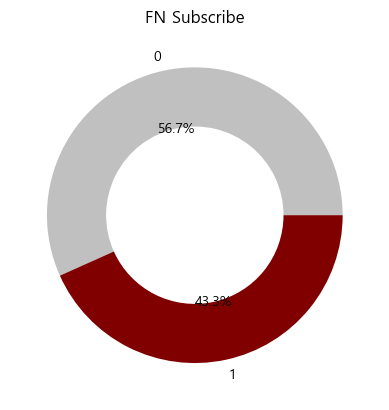

In [14]:
colors = ['silver', 'maroon']

#pie chart
plt.pie(FN_cnt, labels=FN_cnt.index, autopct='%.1f%%', wedgeprops=dict(width=0.4), colors=colors)
plt.title('FN Subscribe')
plt.show()

In [15]:
# FN 구독여부, 알림주기별 고객 수 집계

# 패션뉴스 구독자의 경우 정기적인 알림의 고객이 압도적
# 패션뉴스 비구독자의 경우 잠재고객의 수가 압도적
hm_df2.groupby(['FN','fashion_news_frequency'])['customer_id'].count()

FN  fashion_news_frequency
0   Monthly                        3
    NONE                      453423
    Regularly                   1353
1   Monthly                      254
    NONE                         297
    Regularly                 346655
Name: customer_id, dtype: int64

In [16]:
# FN 구독자인 고객 중 신규/활성/탈퇴 회원인 고객 수 집계 
# 패션뉴스 구독자인 고객 중 신규/활성/탈퇴 회원인 고객
hm_df2[hm_df2['FN'] == 1].groupby(['club_member_status','FN'])['customer_id'].count()


club_member_status  FN
ACTIVE              1     345910
LEFT CLUB           1          2
PRE-CREATE          1       1294
Name: customer_id, dtype: int64

In [17]:
# 패션뉴스FN 구독별 Active별 구독수 집계
#패션뉴스FN 구독 별 Active별 고객수 #insight2
#Active : 커뮤니케이션 활성 여부 0 불가능/1 가능

hm_df2.groupby(['FN','Active'])['customer_id'].count()

FN  Active
0   0         454779
1   0           4952
    1         342254
Name: customer_id, dtype: int64

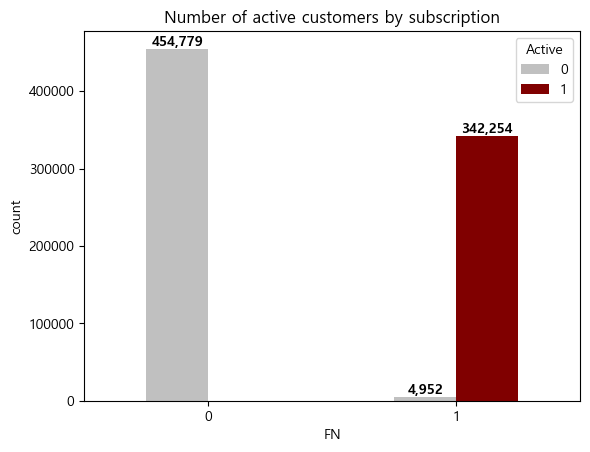

In [18]:
FN_Active_cnt = hm_df2.groupby(['FN','Active'])['customer_id'].count().unstack(1)

ax = FN_Active_cnt.plot(kind='bar', color=['silver', 'maroon'])
plt.title("Number of active customers by subscription")
plt.xlabel("FN")
plt.ylabel("count")

plt.xticks(rotation=0)

# 바 위에 값 추가
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 값이 0보다 클 때만 표시
        ax.text(
            p.get_x() + p.get_width() / 2,  # x 위치 (바의 가운데)
            height,  # y 위치 (바의 높이)
            f'{int(height):,}',  # 천 단위 콤마 추가
            ha='center', va='bottom', fontsize=10, fontweight='bold'  # 정렬 및 폰트 설정
        )

plt.show()


____________________________________________________________________________________________

## 나이대별 고객 현황 ##

4 분위로 분리 및 연령대별 고객 수

In [19]:
age_group = pd.cut(hm_df2['age'], bins=[16, 24, 32, 49, 99], labels=['Young', 'Middle', 'Senior', 'Old'])
age_group_cnt = age_group.value_counts()
print(age_group_cnt)

age
Middle    264072
Senior    210808
Old       170341
Young     156741
Name: count, dtype: int64


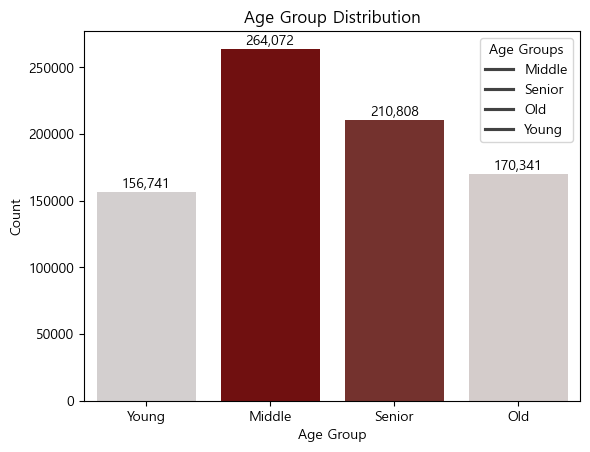

In [20]:
#색상 리스트 직접 지정
colors = ['#D4CFCE', '#800000', '#802722', '#D5CBCA']  

#그래프
sns.barplot(x=age_group_cnt.index, y=age_group_cnt.values, hue=age_group_cnt.index, palette=colors)

#그래프 제목과 라벨 추가
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )

# 범례 추가
plt.legend(title="Age Groups", labels=age_group_cnt.index, loc="upper right")

#그래프 출력
plt.show()

연령대 10단위로 분리 및 연령대 별 고객 수

In [ ]:
#연령대별(10단위로 분류)
ages = pd.cut(hm_df2['age'], bins=[10, 20, 30, 40, 50, 60, 70, 80, 90], labels=['10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s'])
ages_cnt = ages.value_counts()
print(ages_cnt)

age
20s    396739
40s    167396
30s    163090
50s    162036
10s     98147
60s     48996
70s     11319
80s       800
Name: count, dtype: int64


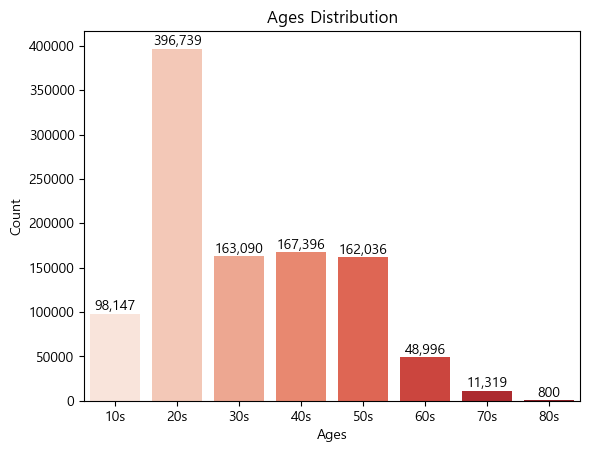

In [22]:
#그래프
sns.barplot(x=ages_cnt.index, y=ages_cnt.values, hue=ages_cnt.index, palette='Reds')

#그래프 제목과 라벨 추가
plt.title('Ages Distribution')
plt.xlabel('Ages')
plt.ylabel('Count')
bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )


#그래프 출력
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_1264\1087920100.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(hm_df2, index=ages,columns='FN', values='customer_id', aggfunc='count').plot.bar(color=['gray', 'maroon'])


(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, '10s'),
  Text(1, 0, '20s'),
  Text(2, 0, '30s'),
  Text(3, 0, '40s'),
  Text(4, 0, '50s'),
  Text(5, 0, '60s'),
  Text(6, 0, '70s'),
  Text(7, 0, '80s')])

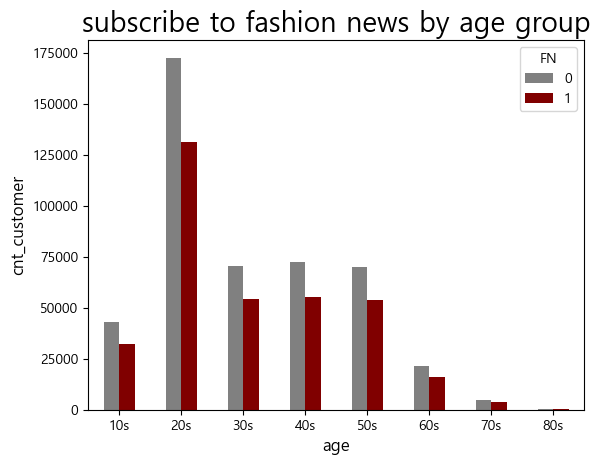

In [23]:
#연령대별(10단위로 분류)
# ages = pd.cut(cus_df['age'], bins=[10, 20, 30, 40, 50, 60, 70, 80, 90], labels=['10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s'])
# ages_cnt = ages.value_counts()
# print(ages_cnt)

pd.pivot_table(hm_df2, index=ages,columns='FN', values='customer_id', aggfunc='count').plot.bar(color=['gray', 'maroon'])
plt.title("subscribe to fashion news by age group",fontsize=20)
plt.xlabel("age",fontsize=12)
plt.ylabel("cnt_customer",fontsize=12)
plt.xticks(rotation=0)

____________________________________________________________________________________________

## 구매 채널 별 ##

In [24]:
# 온라인 / 오프라인 인원 수 카운트
on_off_cnt = hm_df2['sales_channel_id'].value_counts()
print(on_off_cnt)

sales_channel_id
2    555940
1    246045
Name: count, dtype: int64


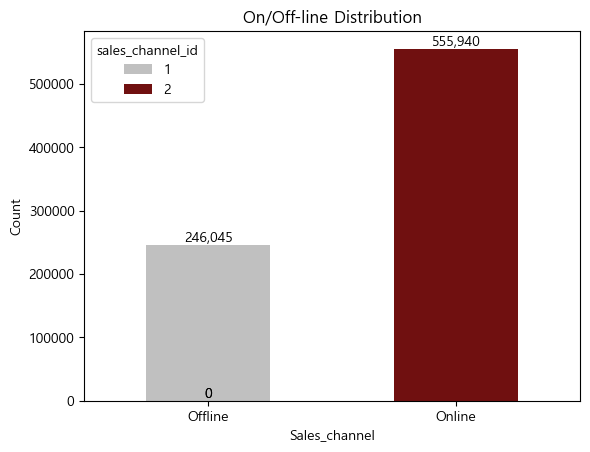

In [25]:
# 그래프 시각화

#색상 리스트 직접 지정
colors = ['silver', 'maroon']  

#그래프
sns.barplot(x=on_off_cnt.index, y=on_off_cnt.values, hue=on_off_cnt.index, palette=colors, width=0.5)


#그래프 제목과 라벨 추가
plt.xticks(ticks=[0, 1], labels=['Offline', 'Online'])
plt.title('On/Off-line Distribution')
plt.xlabel('Sales_channel')
plt.ylabel('Count')

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )

#그래프 출력
plt.show()

____________________________________________________________________________________________

## 회원상태별 ##

In [ ]:
# 회원 상태 별 (기존 / 신규 / 탈퇴) 고객 수 카운트
c_mem_stat = hm_df2.groupby('club_member_status')['customer_id'].count()

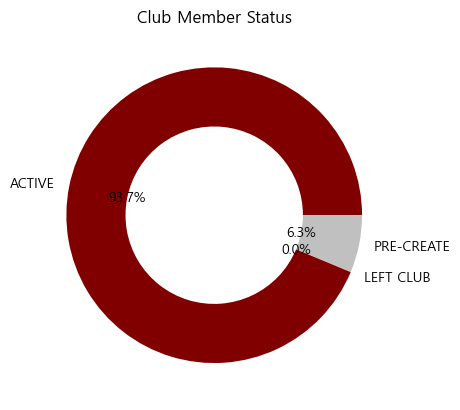

In [27]:
# 도넛 차트 형태로 시각화
plt.pie(c_mem_stat.values, labels=['ACTIVE', 'LEFT CLUB', 'PRE-CREATE'], autopct='%1.1f%%', wedgeprops=dict(width=0.4), colors=['maroon', 'firebrick', 'silver'])
plt.title('Club Member Status')
plt.labels=['a', 'b', 'c']
plt.show()

____________________________________________________________________________________________

## 월/ 요일별 ##

월별 고객 수

In [28]:
# Date time 형식 전환
hm_df2['t_dat'] = pd.to_datetime(hm_df2['t_dat'], errors='coerce')
hm_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 801985 entries, 0 to 803237
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   t_dat                         801985 non-null  datetime64[ns]
 1   customer_id                   801985 non-null  object        
 2   article_id                    801985 non-null  int64         
 3   price                         801985 non-null  float64       
 4   sales_channel_id              801985 non-null  int64         
 5   product_code                  801985 non-null  int64         
 6   prod_name                     801985 non-null  object        
 7   product_type_no               801985 non-null  int64         
 8   product_type_name             801985 non-null  object        
 9   product_group_name            801985 non-null  object        
 10  graphical_appearance_no       801985 non-null  int64         
 11  graphical_appearan

In [29]:
# Month 컬럼 부여
hm_df2['month'] = hm_df2['t_dat'].dt.month

In [30]:
# 월 별 카운트
month_cnt = hm_df2['month'].value_counts()
month_cnt = month_cnt.sort_index()

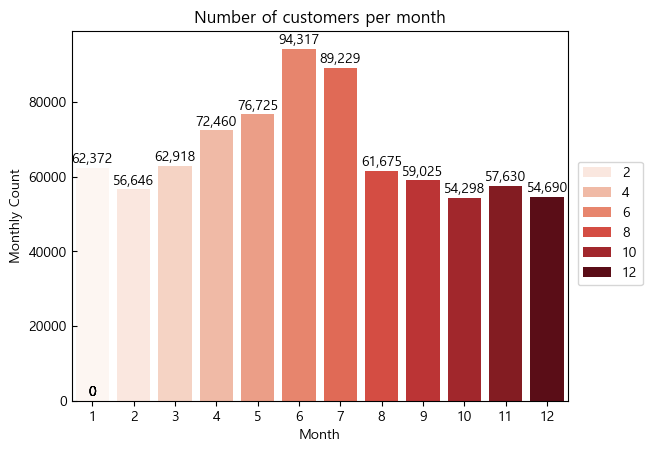

In [31]:
# 월 별 사용 고객 수 시각화
sns.barplot(x=month_cnt.index, y=month_cnt.values, hue=month_cnt.index, palette='Reds')
plt.title('Number of customers per month')
plt.ylabel('Monthly Count')
plt.xlabel('Month')

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )

plt.tick_params(axis='y', direction='in', labelcolor='black')
plt.legend(loc=(1.02, 0.312))
plt.show()

주중/주말 고객수

In [32]:
# Date time 형식 전환
hm_df2['t_dat'] = pd.to_datetime(hm_df2['t_dat'], errors='coerce')
hm_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 801985 entries, 0 to 803237
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   t_dat                         801985 non-null  datetime64[ns]
 1   customer_id                   801985 non-null  object        
 2   article_id                    801985 non-null  int64         
 3   price                         801985 non-null  float64       
 4   sales_channel_id              801985 non-null  int64         
 5   product_code                  801985 non-null  int64         
 6   prod_name                     801985 non-null  object        
 7   product_type_no               801985 non-null  int64         
 8   product_type_name             801985 non-null  object        
 9   product_group_name            801985 non-null  object        
 10  graphical_appearance_no       801985 non-null  int64         
 11  graphical_appearan

In [33]:
# 구매 날짜별 요일 부여
day_n = pd.DataFrame(hm_df2['t_dat'].dt.day_name())

In [34]:
# 요일을 주중 과 주말로 분리
wkd = day_n['t_dat'].apply(lambda x: 'Weekend' if x in['Saturday', 'Sunday'] else 'Weekday')

# 테스트 
# day_n['weekend'] = wkd
# day_n

# hm_df에 주중 주말 컬럼 추가
hm_df2['weekend'] = wkd

In [35]:
# 주중 / 주말 별 고객 수 집계
WK_cnt=hm_df2.groupby('weekend')['customer_id'].count()

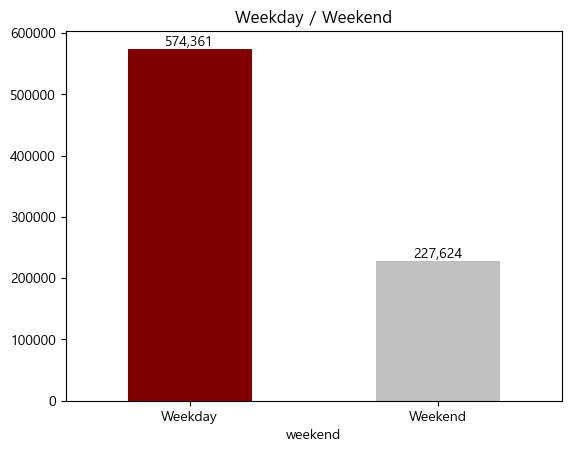

In [36]:
# 주중 / 주말 별 고객 수 집계 시각화
WK_cnt=hm_df2.groupby('weekend')['customer_id'].count().plot.bar(color=['maroon', 'silver'])
plt.title('Weekday / Weekend')
plt.xticks(rotation=0)

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )



____________________________________________________________________________________________

## 구매 횟수 별 고객 수 ##

In [37]:
# 고객 아이디 별 구매 횟수
sales_cnt = hm_df2.groupby('customer_id')['article_id'].count()

In [38]:
# 구매 횟수별 고객 분포 확인
sales_cnt.describe()

count    350761.000000
mean          2.286414
std           2.152701
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          59.000000
Name: article_id, dtype: float64

In [39]:
# 4분위 기준으로 나눠서 고객 수 집계

#개수 
bins = [0, 1, 2, 3, 60]
#범주 이름
labels = ['Q1', 'Q2', 'Q3', 'Q4']  

#범주화
sales_cnt_quantile = pd.cut(sales_cnt, bins=bins, labels=labels, right=True)
sales_cnt1 = sales_cnt_quantile.value_counts()
sales_cnt1

article_id
Q1    174367
Q2     77874
Q4     58671
Q3     39849
Name: count, dtype: int64

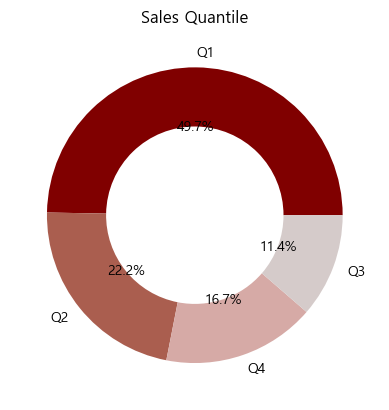

In [40]:
# 시각화
colors = [ '#800000', '#AA5E4F', '#D6AAA6', '#D5CBCA']

#pie chart
plt.pie(sales_cnt1, labels=sales_cnt1.index, autopct='%.1f%%', wedgeprops=dict(width=0.4), colors=colors)
plt.title('Sales Quantile')
plt.show()

##################################################################################################

# 전체 매출 현황 분석 #

1. 제품 카테고리 별
2. 나이대 별
3. 타겟 그룹별
4. 온/오프라인별
    1. 월 별 판매량 및 매출액
5. 월, 요일 별
    1. 주중&주말 고객 수 
    2. 월별 판매 생상 및 카테고리
6. 구매 횟수 별

____________________________________________________________________________________________

- 매출 통계
- 고객 범주화 및 시각화

In [41]:
# 통계
hm_df2['price'].describe()

count    801985.000000
mean      23012.473052
std       13537.013136
min         205.239883
25%       13179.339883
50%       21975.340293
75%       29305.340059
max       73871.740293
Name: price, dtype: float64

In [42]:
# 고객 id당 매출 통계
cus_price = hm_df2.groupby('customer_id')['price'].sum()
cus_price

customer_id
00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657     90862.679604
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa    172900.039927
0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d8cd0c725276a467a2a     21975.340293
00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2     89719.200381
00009d946eec3ea54add5ba56d5210ea898def4b46c68570cf0096d962cacc75    122249.739956
                                                                        ...      
c88f00357e7b1518128c80043e5d2b223308a3ce3fc3893a732de1f232b8034d     51295.340220
c88f0d813c429ceb32683c9cb5fcb24331ff198e6e17f259440f4b220ab8212a     14645.339663
c88f5971612e659a4e90d6f08d9c29bdf1e4268fcf52d56ff8c53e2c24157209     35447.880132
c88f99a55b10f6dd50dd87c3ca05af4a8a6c98f3e6fbc5cf86a1f0aa988df4e9     55664.018959
c88fa15c06519c4bdcab386fea313b226113584b729874e61ba0a8396b4a118f     19043.339868
Name: price, Length: 350761, dtype: float64

In [43]:
#고객 범주화(cus_id 별로 구매 총액 범위가 0-9, 9-15달러 등)
#매출 금액을 범주화 (예: 15000원 이하, 9-15, 15-25, 25 이상)
bins = [0, 10000, 20000, 30000, float('inf')]  # 금액 범위
labels = ['0-10000', '10000-20000', '20000-30000', '30000+']  # 범주 이름
palettes = ['lavender', 'peachpuff', 'lightpink', 'lemonchiffon']
#매출 금액을 범주화
cus_price_binned = pd.cut(cus_price, bins=bins, labels=labels, right=False)

#각 범주별 고객 수 계산
cus_price_binned_counts = cus_price_binned.value_counts()

price
30000+         187453
20000-30000     71591
10000-20000     66001
0-10000         25716
Name: count, dtype: int64


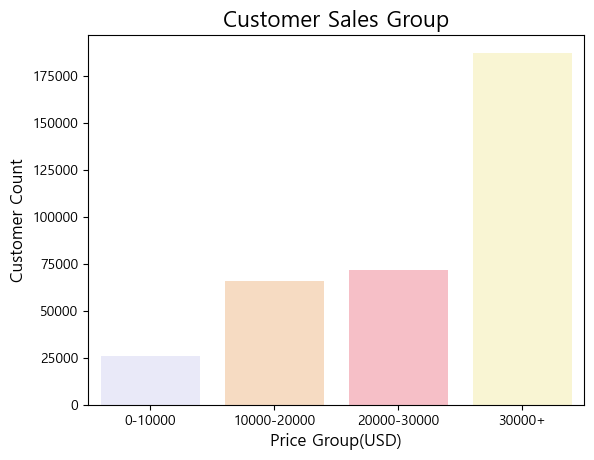

In [44]:
# 시각화
sns.barplot(x=cus_price_binned_counts.index, y=cus_price_binned_counts.values, hue=cus_price_binned_counts.index, palette=palettes)

#그래프 제목 및 레이블 설정
plt.title('Customer Sales Group', fontsize=16)
plt.xlabel('Price Group(USD)', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)

#통계
print(cus_price_binned_counts)

#그래프 출력
plt.show()

In [45]:
# 구매 고객 매출 분석
#고객 아이디, 상품 아이디, 가격 컬럼 슬라이싱
cus_price_df = hm_df2[['customer_id', 'article_id', 'price']]
cus_price_df

#고객별 총 구매 금액
cusP = cus_price_df.groupby('customer_id')['price'].sum()
print(cusP)

#고객별 구매 갯수
cusC = cus_price_df.groupby('customer_id')['article_id'].count()
print(cusC)

#평균 구매 금액 계산
avg_purchase_price = cusP.mean()
avg_purchase_cnt = cusC.mean()

#구매금액 상위 10명 고객
top_10_customers = cusP.sort_values(ascending=False).head(10)

#결과 출력
print("상위 10명 고객별 총 구매 금액:")
print(top_10_customers)

print("\n 전체 고객 평균 구매 금액:", avg_purchase_price)

customer_id
00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657     90862.679604
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa    172900.039927
0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d8cd0c725276a467a2a     21975.340293
00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2     89719.200381
00009d946eec3ea54add5ba56d5210ea898def4b46c68570cf0096d962cacc75    122249.739956
                                                                        ...      
c88f00357e7b1518128c80043e5d2b223308a3ce3fc3893a732de1f232b8034d     51295.340220
c88f0d813c429ceb32683c9cb5fcb24331ff198e6e17f259440f4b220ab8212a     14645.339663
c88f5971612e659a4e90d6f08d9c29bdf1e4268fcf52d56ff8c53e2c24157209     35447.880132
c88f99a55b10f6dd50dd87c3ca05af4a8a6c98f3e6fbc5cf86a1f0aa988df4e9     55664.018959
c88fa15c06519c4bdcab386fea313b226113584b729874e61ba0a8396b4a118f     19043.339868
Name: price, Length: 350761, dtype: float64
customer_id
00000dbacae5abe5e23885899a1fa4

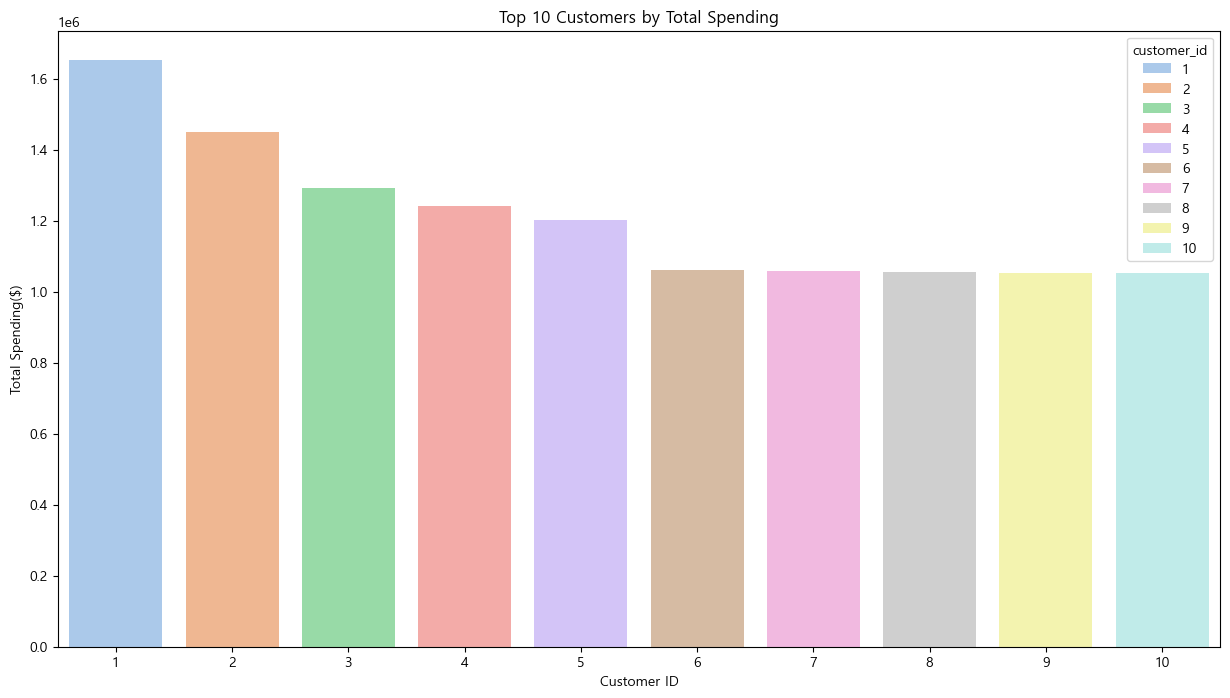

In [46]:
#series를 DF로 변환
top_10_customers_df = top_10_customers.reset_index()
top_10_customers_df.columns = ['customer_id', 'price']

#cus_id 너무 길어서 1-10의 값으로 변경
top_10_customers_df['customer_id'] = range(1, len(top_10_customers_df) + 1)

#그래프
plt.figure(figsize=(15, 8))
sns.barplot(x='customer_id', y='price', data=top_10_customers_df, palette='pastel',hue='customer_id', legend=True)

#그래프 제목 및 라벨 추가
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending($)')
plt.show()

____________________________________________________________________________________________

## 제품 카테고리별 ##

In [47]:
# 상품 종류별 매출액 
p_type = hm_df2.groupby('product_type_name')['price'].sum().sort_values(ascending=False).head(10).reset_index()

C:\Users\user\AppData\Local\Temp\ipykernel_1264\2590558935.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()])


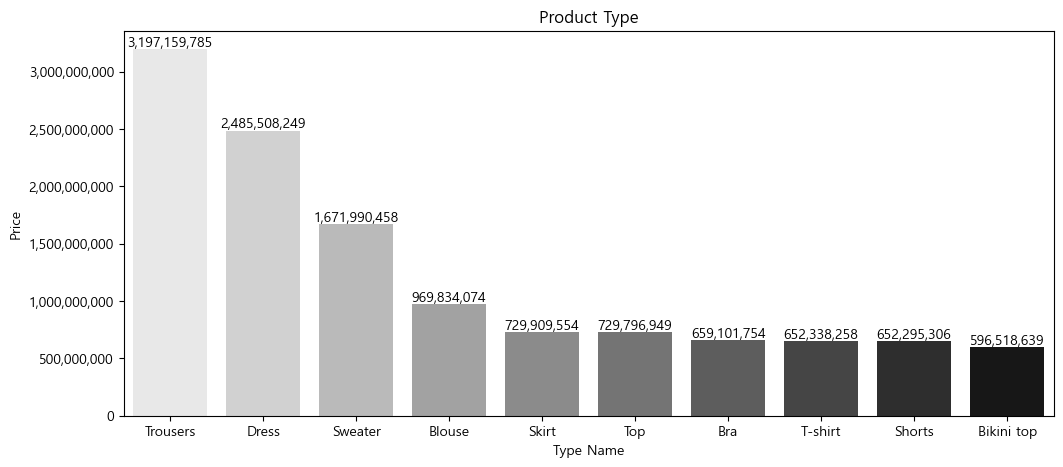

In [48]:
# 시각화
plt.figure(figsize=(12,5))
sns.barplot(p_type, x='product_type_name', y='price', hue='product_type_name', palette='binary')
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()])
plt.xlabel('Type Name')
plt.ylabel('Price')
plt.title('Product Type')

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )


plt.show()

In [49]:
# 상품 종류 별 판배 수 항목 추가
#상품 종류 별 판매 수 항목 추가
p_type = pd.DataFrame(hm_df2.groupby('product_type_name')['price'].sum().sort_index())
p_type['cnt'] = pd.DataFrame(hm_df2.groupby('product_type_name')['t_dat'].count().sort_index())
p_type = p_type.sort_values('price', ascending=False).head(10)
p_type

,price,cnt
product_type_name,,
Trousers,3.197160e+09,105241
Dress,2.485508e+09,80484
Sweater,1.671990e+09,70168
Blouse,9.698341e+08,40400
Skirt,7.299096e+08,23570
Top,7.297969e+08,41671
Bra,6.591018e+08,31775
T-shirt,6.523383e+08,55982
Shorts,6.522953e+08,32978


C:\Users\user\AppData\Local\Temp\ipykernel_1264\3761139524.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=p_type.index, y=p_type['price'], ax=ax1, palette='binary',  label='Total Sales')
C:\Users\user\AppData\Local\Temp\ipykernel_1264\3761139524.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()], color='black')


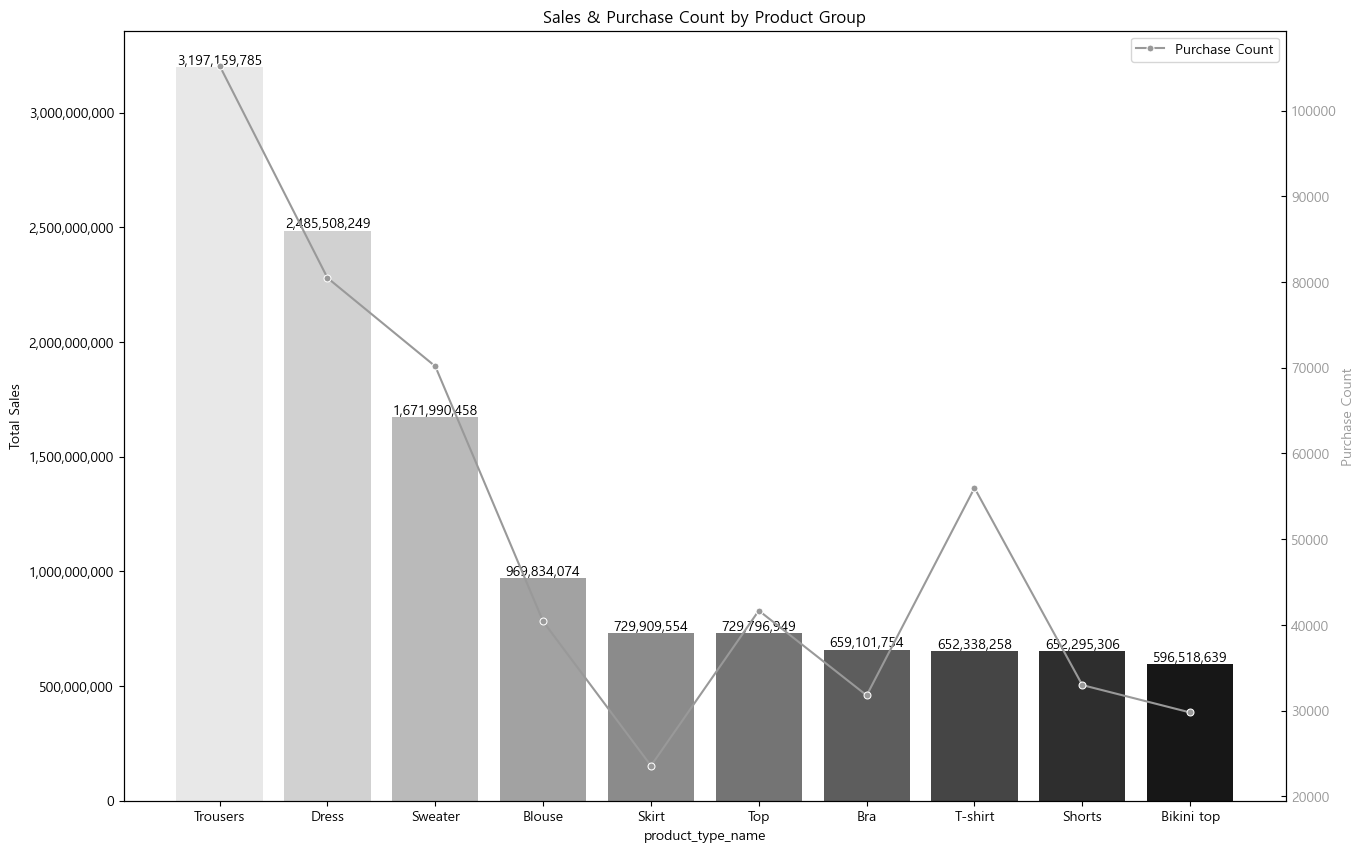

In [50]:
# 시각화
#매출액, 판매개수 이중축 그래프 (상위 5개 카테고리만 자를까..)
#이중축 그래프 생성
fig, ax1 = plt.subplots(figsize=(15, 10))

#첫 번째 축(막대그래프: 매출액)
sns.barplot(x=p_type.index, y=p_type['price'], ax=ax1, palette='binary',  label='Total Sales')
ax1.set_ylabel('Total Sales', color='black')
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()], color='black')

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )


#두 번째 축(라인그래프: 구매 건수)
ax2 = ax1.twinx()
sns.lineplot(x=p_type.index, y=p_type['cnt'], ax=ax2, color='#999999', marker='o', markersize=5, label='Purchase Count')
ax2.set_ylabel('Purchase Count', color='#999999')
ax2.tick_params(axis='y', direction='in', labelcolor='#999999')


#레이블 위치 설정
ax1.set_zorder(ax2.get_zorder())
ax1.patch.set_visible(False)


#제목 및 범례 추가
plt.title('Sales & Purchase Count by Product Group')
ax2.legend(loc='upper right')


# #그래프 출력
plt.show()

In [51]:
# 제품군 별 매출액
p_group = hm_df2.groupby('product_group_name')['price'].sum().sort_values(ascending=False).head(10).reset_index()

C:\Users\user\AppData\Local\Temp\ipykernel_1264\137213618.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()])


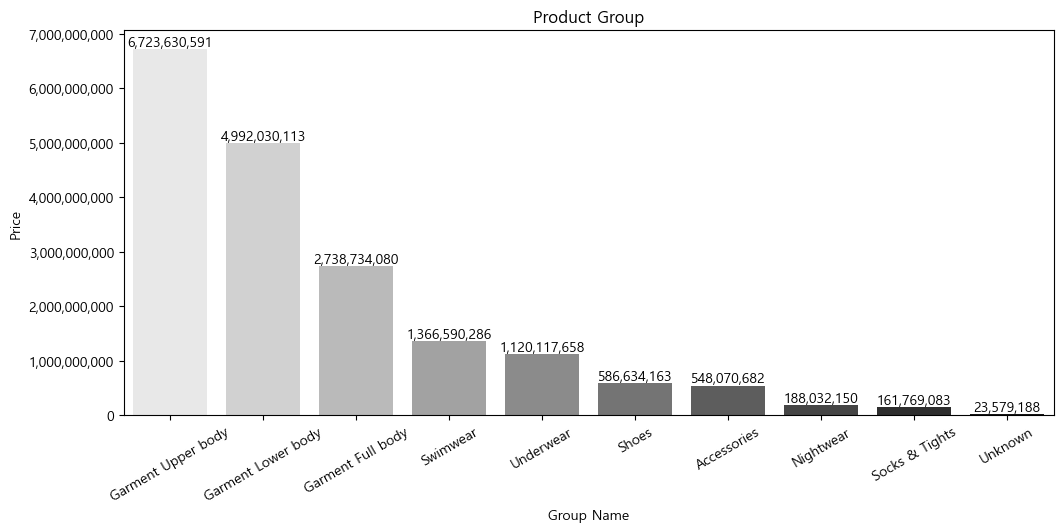

In [52]:
# 시각화
plt.figure(figsize=(12,5))
sns.barplot(p_group, x='product_group_name', y='price', hue='product_group_name', palette='binary')
plt.xticks(rotation=30)
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()])
plt.xlabel('Group Name')
plt.ylabel('Price')
plt.title('Product Group')

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )


In [53]:
# 대분류 매출액
g_group = hm_df2.groupby('garment_group_name')['price'].sum().sort_values(ascending=False).head(10).reset_index()

C:\Users\user\AppData\Local\Temp\ipykernel_1264\691107298.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()])


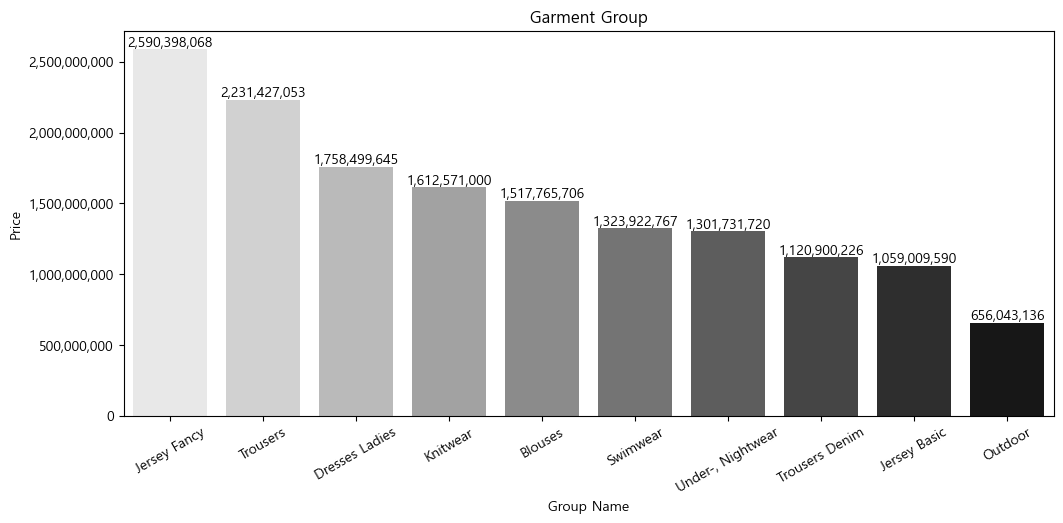

In [54]:
# 시각화
plt.figure(figsize=(12,5))
sns.barplot(g_group, x='garment_group_name', y='price', hue='garment_group_name', palette='binary')
plt.xticks(rotation=30)
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()])
plt.xlabel('Group Name')
plt.ylabel('Price')
plt.title('Garment Group')

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )


In [55]:
# 중분류 별 매출액
inx = hm_df2.groupby('index_name')['price'].sum().sort_values(ascending=False).head(5).reset_index()

C:\Users\user\AppData\Local\Temp\ipykernel_1264\2657625477.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()])


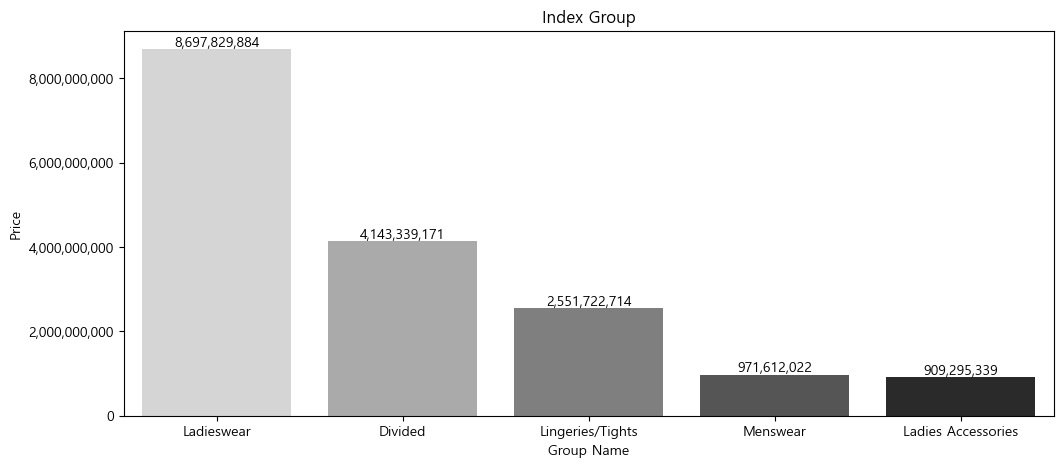

In [56]:
# 시각화 
plt.figure(figsize=(12,5))
sns.barplot(inx, x='index_name', y='price', hue='index_name', palette='binary')
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()])
plt.xlabel('Group Name')
plt.ylabel('Price')
plt.title('Index Group')

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )

In [57]:
# 내가 한거
# A1: 충성고객/ A2: 잠재 충성고객/ A3: 잠재 이탈고객/ A4: 탈퇴고객
A1 = hm_df2.where((hm_df2['FN'] == 1) & (hm_df2['Active'] == 1) & (hm_df2['club_member_status'] == 'ACTIVE'))
A2 = hm_df2.where((hm_df2['FN'] == 0) & (hm_df2['Active'] == 1) & (hm_df2['club_member_status'].isin(['ACTIVE', 'PRE-CREATE'])))
A3 = hm_df2.where((hm_df2['FN'] == 0) & (hm_df2['Active'] == 0) & (hm_df2['club_member_status'].isin(['ACTIVE', 'PRE-CREATE'])))
A4 = hm_df2.where((hm_df2['FN'] == 0) & (hm_df2['Active'] == 0) & (hm_df2['club_member_status'] == 'LEFT CLUB'))

print("충성 고객 수:", A1['customer_id'].nunique())
print("잠재 충성 고객 수:", A2['customer_id'].nunique())
print("잠재 이탈 고객 수:", A3['customer_id'].nunique())
print("탈퇴 고객 수:", A4['customer_id'].nunique())

충성 고객 수: 139797
잠재 충성 고객 수: 0
잠재 이탈 고객 수: 207587
탈퇴 고객 수: 108


In [58]:
# 소분류 별 매출액
dep = hm_df2.groupby('department_name')['price'].sum().sort_values(ascending=False).head(15).reset_index()

C:\Users\user\AppData\Local\Temp\ipykernel_1264\38973397.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()])


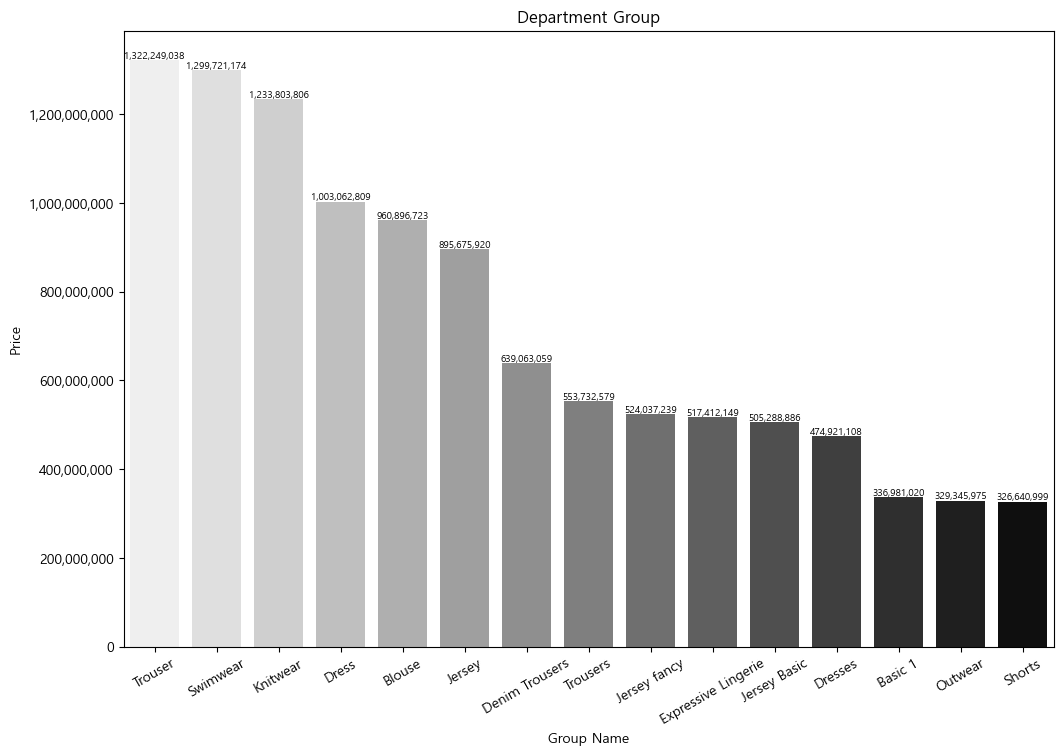

In [59]:
# 시각화
plt.figure(figsize=(12,8))
sns.barplot(dep, x='department_name', y='price', hue='department_name', palette='binary')
plt.xticks(rotation=30)
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in plt.gca().get_yticks()])
plt.xlabel('Group Name')
plt.ylabel('Price')
plt.title('Department Group')

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height * 1,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=7, rotation=0 # 가운데 정렬 및 폰트 크기 설정
    )

In [60]:
# 제품군중 제일 잘팔리는 제품명과 가격 - 현진
# (product_type_name 상품 종류 명, product_group_name 제품군)

#product_group_name별 product_type_name 개수 구하기
type_counts = hm_df2.groupby('product_group_name')['product_type_name'].nunique().reset_index()
type_counts.rename(columns={'product_type_name': 'type_count'}, inplace=True)

#기존 most_sold_products 만들기
most_sold_products = hm_df2.loc[hm_df2.groupby('product_group_name')['customer_id'].idxmax(),['product_group_name', 'product_type_name', 'price']
                                ]

#병합
most_sold_products = most_sold_products.merge(type_counts, on='product_group_name', how='left')
most_sold_products

,product_group_name,product_type_name,price,type_count
0,Accessories,Hair/alice band,733.000323,36
1,Bags,Weekend/Gym bag,58625.339985,4
2,Cosmetic,Fine cosmetics,2330.939780,2
3,Furniture,Side table,9191.820308,1
4,Garment Full body,Dress,14176.220425,6
5,Garment Lower body,Trousers,19043.339868,5
6,Garment Upper body,Tailored Waistcoat,51295.340220,15
7,Garment and Shoe care,Sewing kit,14645.339663,2
8,Items,Umbrella,10540.540279,3
9,Nightwear,Pyjama set,20509.339648,4


____________________________________________________________________________________________

## 나이대 별 ##

In [61]:
print(hm_df2.columns)

Index(['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id',
       'product_code', 'prod_name', 'product_type_no', 'product_type_name',
       'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc', 'FN', 'Active',
       'club_member_status', 'fashion_news_frequency', 'age', 'Z-score',
       'z-score_age', 'month', 'weekend'],
      dtype='object')


In [62]:
pd.options.display.float_format = '{:,.0f}'.format

hm_df2['age_group'] = hm_df2['age'].apply(lambda x : '10대' if x<20 else
                    '20대' if x<30 else
                    '30대' if x<40 else
                    '40대' if x<50 else
                    '50대' if x<60 else
                    '60대' if x<70 else
                    '70대' if x<80 else
                    '80대' if x<90 else
                    '90살이상'
)

#나이대별 평균 매출액
age_sale = hm_df2.groupby('age_group')['price'].agg('sum','avg')
age_sale

age_group
10대     276,057,607
20대   7,461,731,918
30대   3,770,851,702
40대   2,843,478,737
50대   3,220,556,015
60대     770,514,763
70대     112,467,459
Name: price, dtype: float64

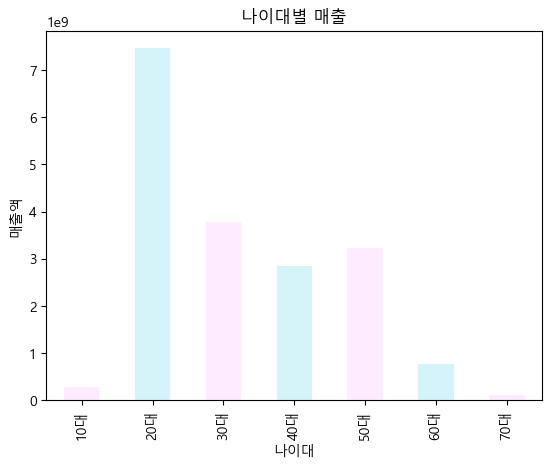

In [63]:
import matplotlib.ticker as ticker
# y축의 지수 표기 제거
#plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))


dplot8=age_sale.plot(kind='bar',color = ['#FFEBFF', '#D4F4FA'])
plt.title('나이대별 매출')
plt.xlabel('나이대')
plt.ylabel('매출액')
plt.show()

____________________________________________________________________________________________

## 타겟 그룹 별 ##

In [64]:
# 타겟 그룹 별 고객 수
target_group=hm_df2.groupby('index_group_name')['customer_id'].count()

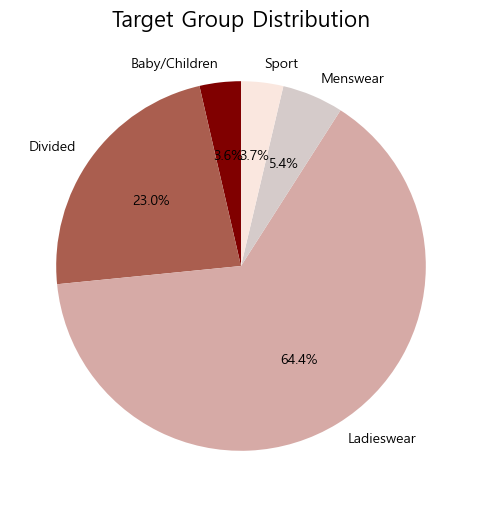

In [65]:
import matplotlib.pyplot as plt

# 그룹화하여 고객 수 계산
target_group = hm_df2.groupby('index_group_name')['customer_id'].count()

# 파이 차트 그리기
target_group_p = plt.figure(figsize=(6, 6))  # 그래프 크기 조정
plt.pie(
    x=target_group.values,  # 데이터 값 (고객 수)
    labels=target_group.index,  # 레이블 (index_group_name)
    autopct='%1.1f%%',  # 소수점 첫째 자리까지 표시
    colors=['#800000', '#AA5E4F', '#D6AAA6', '#D5CBCA', '#FAE7DF'],  # 색상 설정
    startangle=90  # 시작 각도 설정
)

# 제목 추가
plt.title('Target Group Distribution', fontsize=16)

# 그래프 출력
plt.show()


In [66]:
# 타겟 그룹 별 매출
target_group1=hm_df2.groupby('index_group_name')['price'].sum()

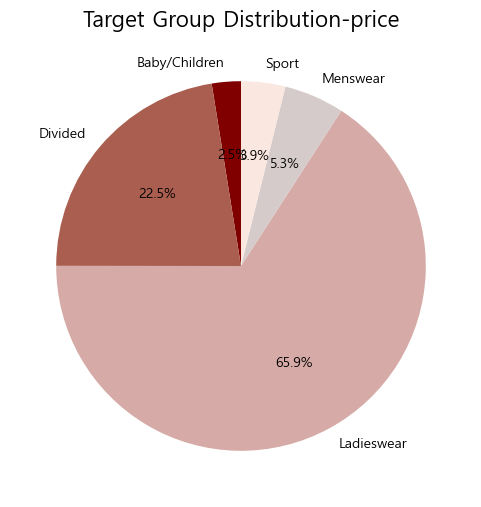

In [67]:
import matplotlib.pyplot as plt

# 그룹화하여 고객 수 계산
target_group1 = hm_df2.groupby('index_group_name')['price'].sum()

# 파이 차트 그리기
target_group_p1 = plt.figure(figsize=(6, 6))  # 그래프 크기 조정
plt.pie(
    x=target_group1.values,  # 데이터 값 (고객 수)
    labels=target_group1.index,  # 레이블 (index_group_name)
    autopct='%1.1f%%',  # 소수점 첫째 자리까지 표시
    colors=['#800000', '#AA5E4F', '#D6AAA6', '#D5CBCA', '#FAE7DF'],  # 색상 설정
    startangle=90  # 시작 각도 설정
)

# 제목 추가
plt.title('Target Group Distribution-price', fontsize=16)

# 그래프 출력
plt.show()

____________________________________________________________________________________________

## 온/오프라인 별 ##

In [68]:
# 판매채널(온/오프라인)별 매출액 합계 (1:오프라인/2:온라인)

## 온/오프라인 별 매출액 (1:오프라인/2:온라인)
onoff_sum= hm_df2.groupby('sales_channel_id')['price'].sum().reset_index()

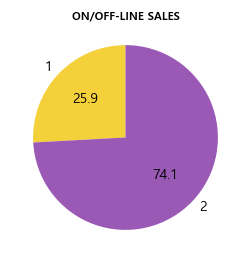

In [69]:
# 시각화 코드 (파이차트)
dplot6= plt.figure(figsize=(3,3))
plt.pie(
    x=onoff_sum['price'], 
    labels=onoff_sum['sales_channel_id'], 
    # 소수점 첫째자리까지 표시
    autopct='%1.1f',
    colors=['#F4D13B','#9b59b6'], 
    startangle=90, #각도 변경
)
plt.title("ON/OFF-LINE SALES", loc="center", pad=1, fontsize=8, fontweight="bold")
plt.show()

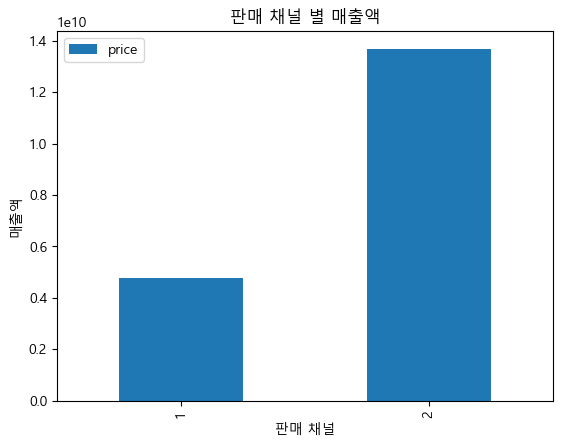

In [70]:
# 시각화 코드(bar)
onoff_sum.plot(kind='bar', x='sales_channel_id', y='price', title='판매 채널 별 매출액', xlabel='판매 채널', ylabel='매출액')
plt.show()

____________________________________________________________________________________________

## 월/요일 별 ##

월별 매출액

In [71]:
# 월별 매출
month_price=hm_df2.groupby(hm_df2['t_dat'].dt.month)['price'].sum()

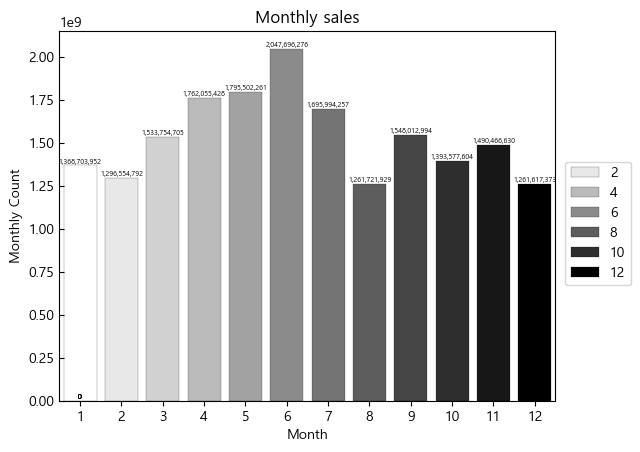

In [72]:
# 월 별 매출 시각화
sns.barplot(x=month_price.index, y=month_price.values, hue=month_price.index, palette='binary',linewidth=0.15, edgecolor='black')
plt.title('Monthly sales')
plt.ylabel('Monthly Count')
plt.xlabel('Month')
plt.tick_params(axis='y', direction='in', labelcolor='black')
plt.legend(loc=(1.02, 0.312))

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=5  # 가운데 정렬 및 폰트 크기 설정
    )

plt.show()

주중/주말 매출액

In [73]:
# 주중/주말 매출액용 데이터 프레임 생성
#날짜만
day_df = hm_df2[['t_dat']]
day_df

#요일 추출
day_df = day_df.copy()
day_df['t_dat'] = pd.to_datetime(day_df['t_dat'])
day_df['day_of_week'] = day_df['t_dat'].dt.day_name()

day_df

#주말 평일 구분
day_df['weekend_or_weekday'] = day_df['day_of_week'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')
day_df

#매출액 추가
day_df['price'] = hm_df2[['price']]
day_df

#월 추가
day_df['month'] = hm_df2[['month']]
day_df

,t_dat,day_of_week,weekend_or_weekday,price,month
0,2019-11-05,Tuesday,Weekday,"14,645",11
1,2019-05-22,Wednesday,Weekday,"29,305",5
2,2019-05-10,Friday,Weekday,"14,645",5
3,2019-08-26,Monday,Weekday,"29,305",8
4,2019-08-10,Saturday,Weekend,"2,785",8
...,...,...,...,...,...
803233,2019-03-25,Monday,Weekday,"21,975",3
803234,2019-10-18,Friday,Weekday,"14,645",10
803235,2019-04-06,Saturday,Weekend,"18,794",4
803236,2019-03-20,Wednesday,Weekday,"14,645",3


In [74]:
# 매출액 비교
#평일 매출액(평일이 더 높음)
weekday_df = day_df[day_df['weekend_or_weekday']=='Weekday']
weekday_sales_price = weekday_df['price'].sum()
print(weekday_sales_price)

#주말 매출액
weekend_df = day_df[day_df['weekend_or_weekday']=='Weekend']
weekend_sales_price = weekend_df['price'].sum()
print(weekend_sales_price)

#평일과 주말 매출액을 리스트로 저장
labels = ['Weekday', 'Weekend']
sales = [weekday_sales_price, weekend_sales_price]

13227602323.831686
5228055876.717488


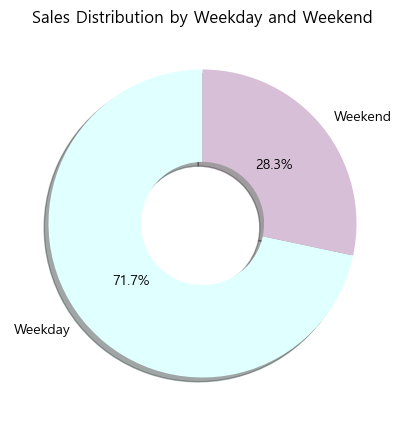

In [75]:
# 시각화
#파이차트로 시각화
plt.figure(figsize=(5, 5))
plt.pie(sales, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightcyan', 'thistle'], shadow=True, wedgeprops={'width': 0.6})

#제목 추가
plt.title('Sales Distribution by Weekday and Weekend')

#그래프 출력
plt.show()

    month weekend_or_weekday         price
0       1            Weekday 1,016,273,873
1       1            Weekend   352,430,079
2       2            Weekday   906,407,568
3       2            Weekend   390,147,224
4       3            Weekday 1,028,438,316
5       3            Weekend   505,316,389
6       4            Weekday 1,281,937,042
7       4            Weekend   480,118,386
8       5            Weekday 1,373,533,865
9       5            Weekend   421,968,396
10      6            Weekday 1,441,714,505
11      6            Weekend   605,981,771
12      7            Weekday 1,318,563,542
13      7            Weekend   377,430,715
14      8            Weekday   933,199,143
15      8            Weekend   328,522,786
16      9            Weekday   968,798,373
17      9            Weekend   579,214,621
18     10            Weekday 1,050,420,869
19     10            Weekend   343,156,735
20     11            Weekday 1,051,466,700
21     11            Weekend   438,999,930
22     12  

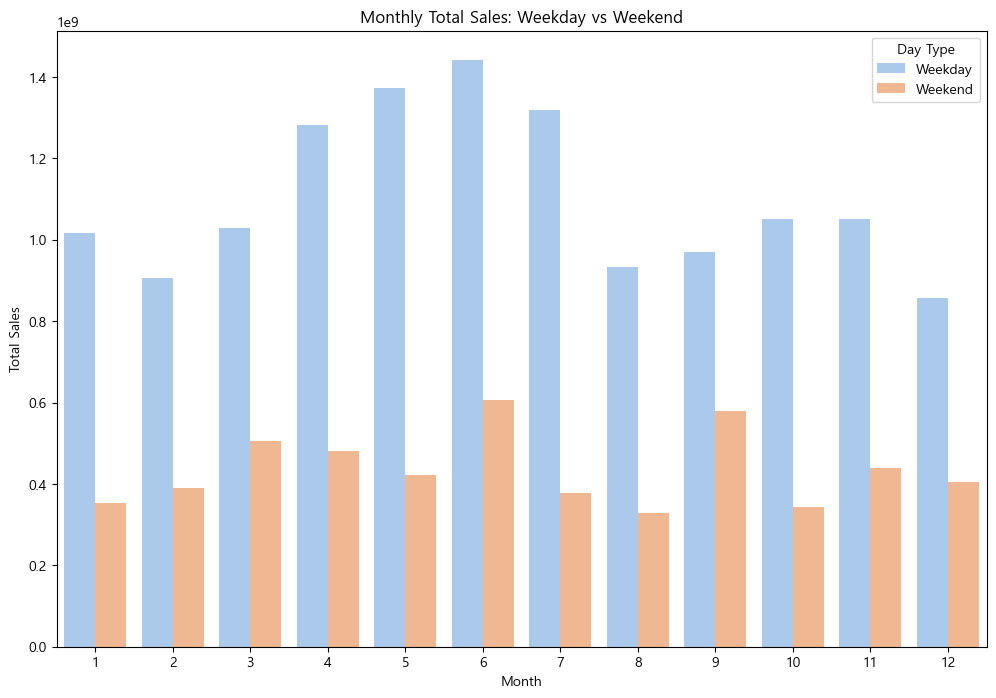

In [76]:
#월별 주말, 평일 매출액 계산
monthly_sales = day_df.groupby(['month', 'weekend_or_weekday'])['price'].sum().reset_index()
print(monthly_sales)

#그래프 그리기
plt.figure(figsize=(12,8))
sns.barplot(x='month', y='price', hue='weekend_or_weekday', data=monthly_sales, palette='pastel')

#그래프 설정
plt.title('Monthly Total Sales: Weekday vs Weekend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend(title="Day Type")
plt.show()

_

In [77]:
# 요일별 매출(그래프 아래에 있음)
hm_df2.groupby(hm_df2['t_dat'].dt.day_name())['price'].sum()

t_dat
Friday      2,661,606,162
Monday      2,417,726,550
Saturday    2,818,052,097
Sunday      2,410,003,780
Thursday    2,800,702,265
Tuesday     2,526,765,416
Wednesday   2,820,801,930
Name: price, dtype: float64

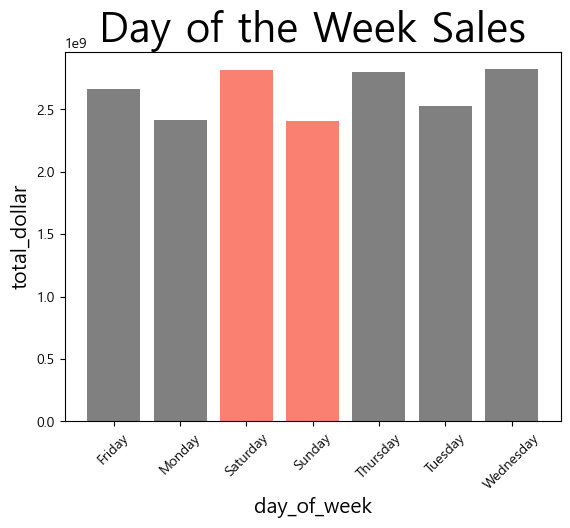

In [78]:
# 요일별 매출
from matplotlib import pyplot as plt

day_of_week=hm_df2.groupby(hm_df2['t_dat'].dt.day_name())['price'].sum()

plt.figure()
plt.bar(day_of_week.index, day_of_week.values,color=['gray','gray','salmon','salmon','gray','gray','gray'])

plt.title('Day of the Week Sales', fontsize=30)
plt.xlabel('day_of_week', fontsize=15)
plt.ylabel('total_dollar', fontsize=15)

plt.xticks(rotation=45)

# plt.xticks(rotation=90)
# plt.yticks(rotation=0)  

# plt.grid(False)

plt.show()

In [79]:
WK_price=hm_df2.groupby('weekend')['price'].sum()

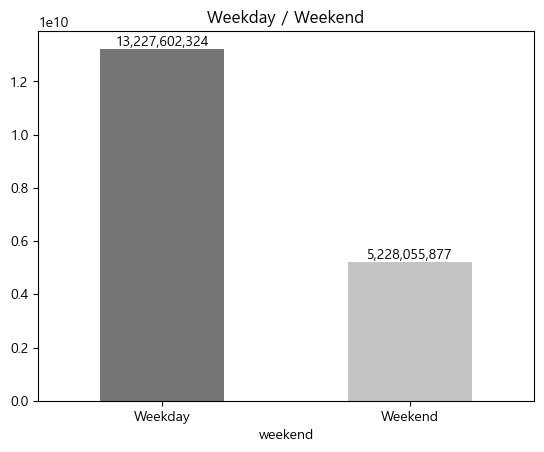

In [80]:
import matplotlib.ticker as mticker

# 주중 주말 매출 시각화
WK_price=hm_df2.groupby('weekend')['price'].sum().plot.bar(color=['#767676', '#C4C4C4'])
plt.title('Weekday / Weekend')
bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
plt.xticks(rotation=0)

bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )



월별 판매 색상 및 카테고리 상관관계

- 색상별 월별 전체 판매 개수 파악
    - 판매량 계산
- 색상별 월별 섹션 판매 개수 파악
    - 판매량 계산

In [81]:
# 월별 많이 판매된 색상
#데이터프레임 생성
monthly_sales = hm_df2[['customer_id', 'article_id', 'month', 'colour_group_code', 'colour_group_name', 'section_no']].copy()
print(monthly_sales)

#각 색상별 월별 몇개씩 판매되었는지 파악
d1 = monthly_sales.groupby(['colour_group_name', 'month', 'colour_group_code'])['customer_id'].count().reset_index()
print(d1)

#피벗 테이블(판매량 계산)
pivot_data = d1.pivot_table(index = 'month', columns='colour_group_code', values='customer_id', aggfunc='sum', fill_value=0)
# 결과 확인
print(pivot_data)


                                              customer_id  article_id  month  \
0       3e2b60b679e62fb49516105b975560082922011dd752ec...   698328010     11   
1       89647ac2274f54c770aaa4b326e0eea09610c252381f37...   760597002      5   
2       2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...   488561032      5   
3       7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...   682771001      8   
4       3b77905de8b32045f08cedb79200cdfa477e9562429a39...   742400033      8   
...                                                   ...         ...    ...   
803233  8e900818a1da0e73300a012794615993fbefb43f851430...   766346001      3   
803234  13aa106eeb8a6fa2f9e2ab888a3a2ee118a3900670f0d8...   811905001     10   
803235  5f51e21397c1248aafdf9712435bd4be063eb093f56229...   690108001      4   
803236  3421bd479ee13287a65660cf816b01d0d803d1d6d0fe73...   583534002      3   
803237  5813663221b265eba9e4604e482be951d9a97ae022a88a...   554811018      1   

        colour_group_code colour_group_

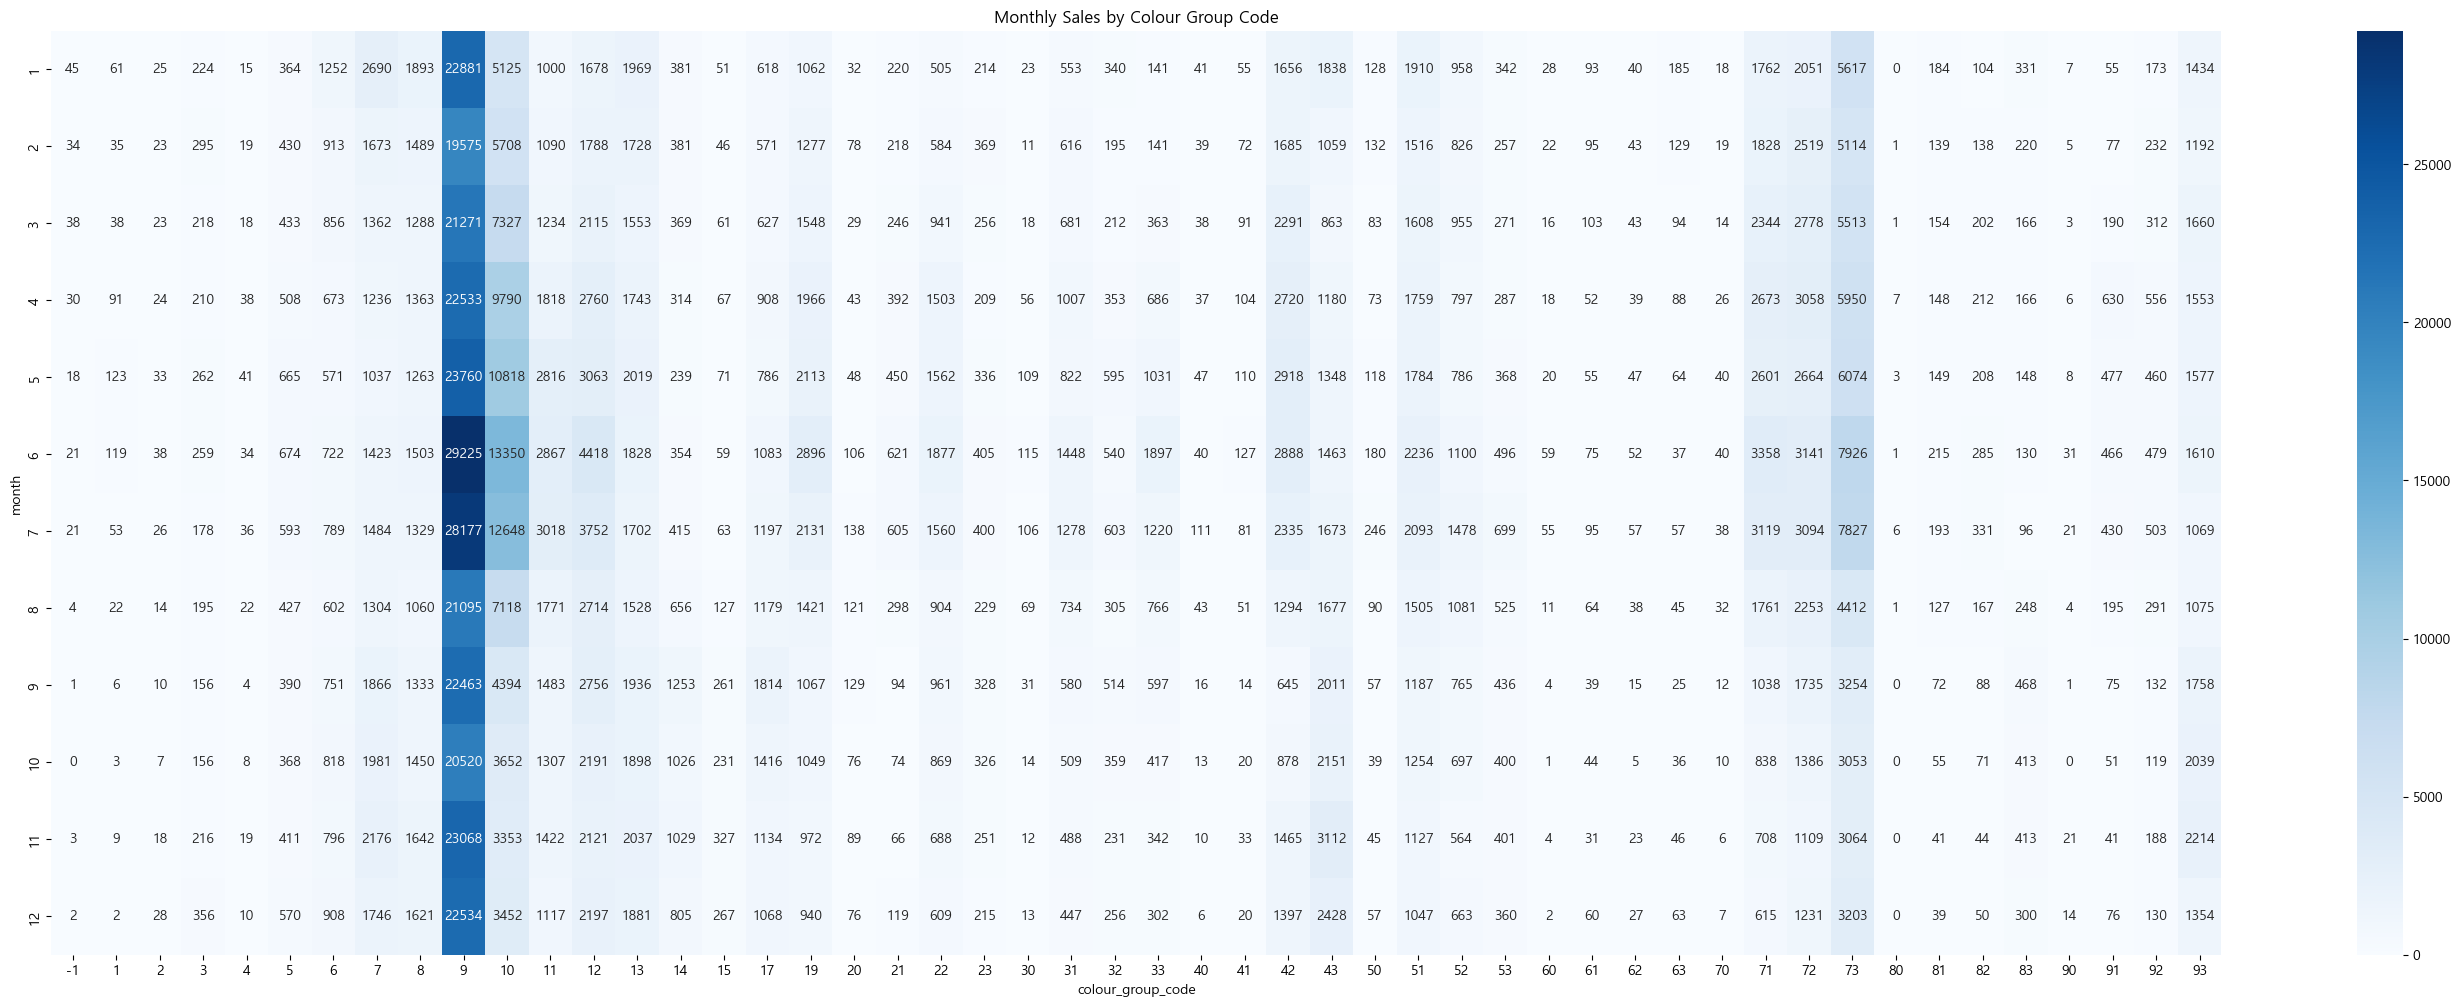

In [82]:
#사이즈
plt.figure(figsize=(35, 12)) 

#히트맵 그리기
sns.heatmap(pivot_data, annot=True, cmap='Blues', fmt='d')

#타이틀
plt.title('Monthly Sales by Colour Group Code')

#그래프 출력
plt.show()

- 9번 컬러 ⇒ Black
- 10번 컬러 ⇒ White

In [83]:
# 월 별 많이 판매된 카테고리
#각 색상별 월별 섹션이 몇개씩 판매되었는지 파악
d2 = monthly_sales.groupby(['section_no', 'month'])['customer_id'].count().reset_index()
print(d2.head())

#피벗 테이블(판매량 계산)
pivot_data2 = d2.pivot_table(index = 'month', columns='section_no', values='customer_id', aggfunc='sum', fill_value=0)
# 결과 확인
print(pivot_data2.head())

   section_no  month  customer_id
0           2      1         1023
1           2      2          920
2           2      3         1160
3           2      4         1395
4           2      5         1244
section_no    2   4     5     6    8     11   14     15    16  17  ...    66  \
month                                                              ...         
1           1023   3  3061  2082  394  3276  370  10007  2840   2  ...  1061   
2            920   0  2247  1805  406  3512  220   9162  2868   0  ...  1406   
3           1160   4  2402  2269  547  4786  278  11016  3079   0  ...  1372   
4           1395   2  2381  3066  625  4762  153  13653  4014   0  ...  1631   
5           1244   1  2366  3500  529  4333  154  14894  3810   0  ...  1734   

section_no  70  71   72   76   77   79   80   82   97  
month                                                  
1           47  22  328  565  782  436   20   61  237  
2           52  24  277  504  837  455   17   47  136  
3          

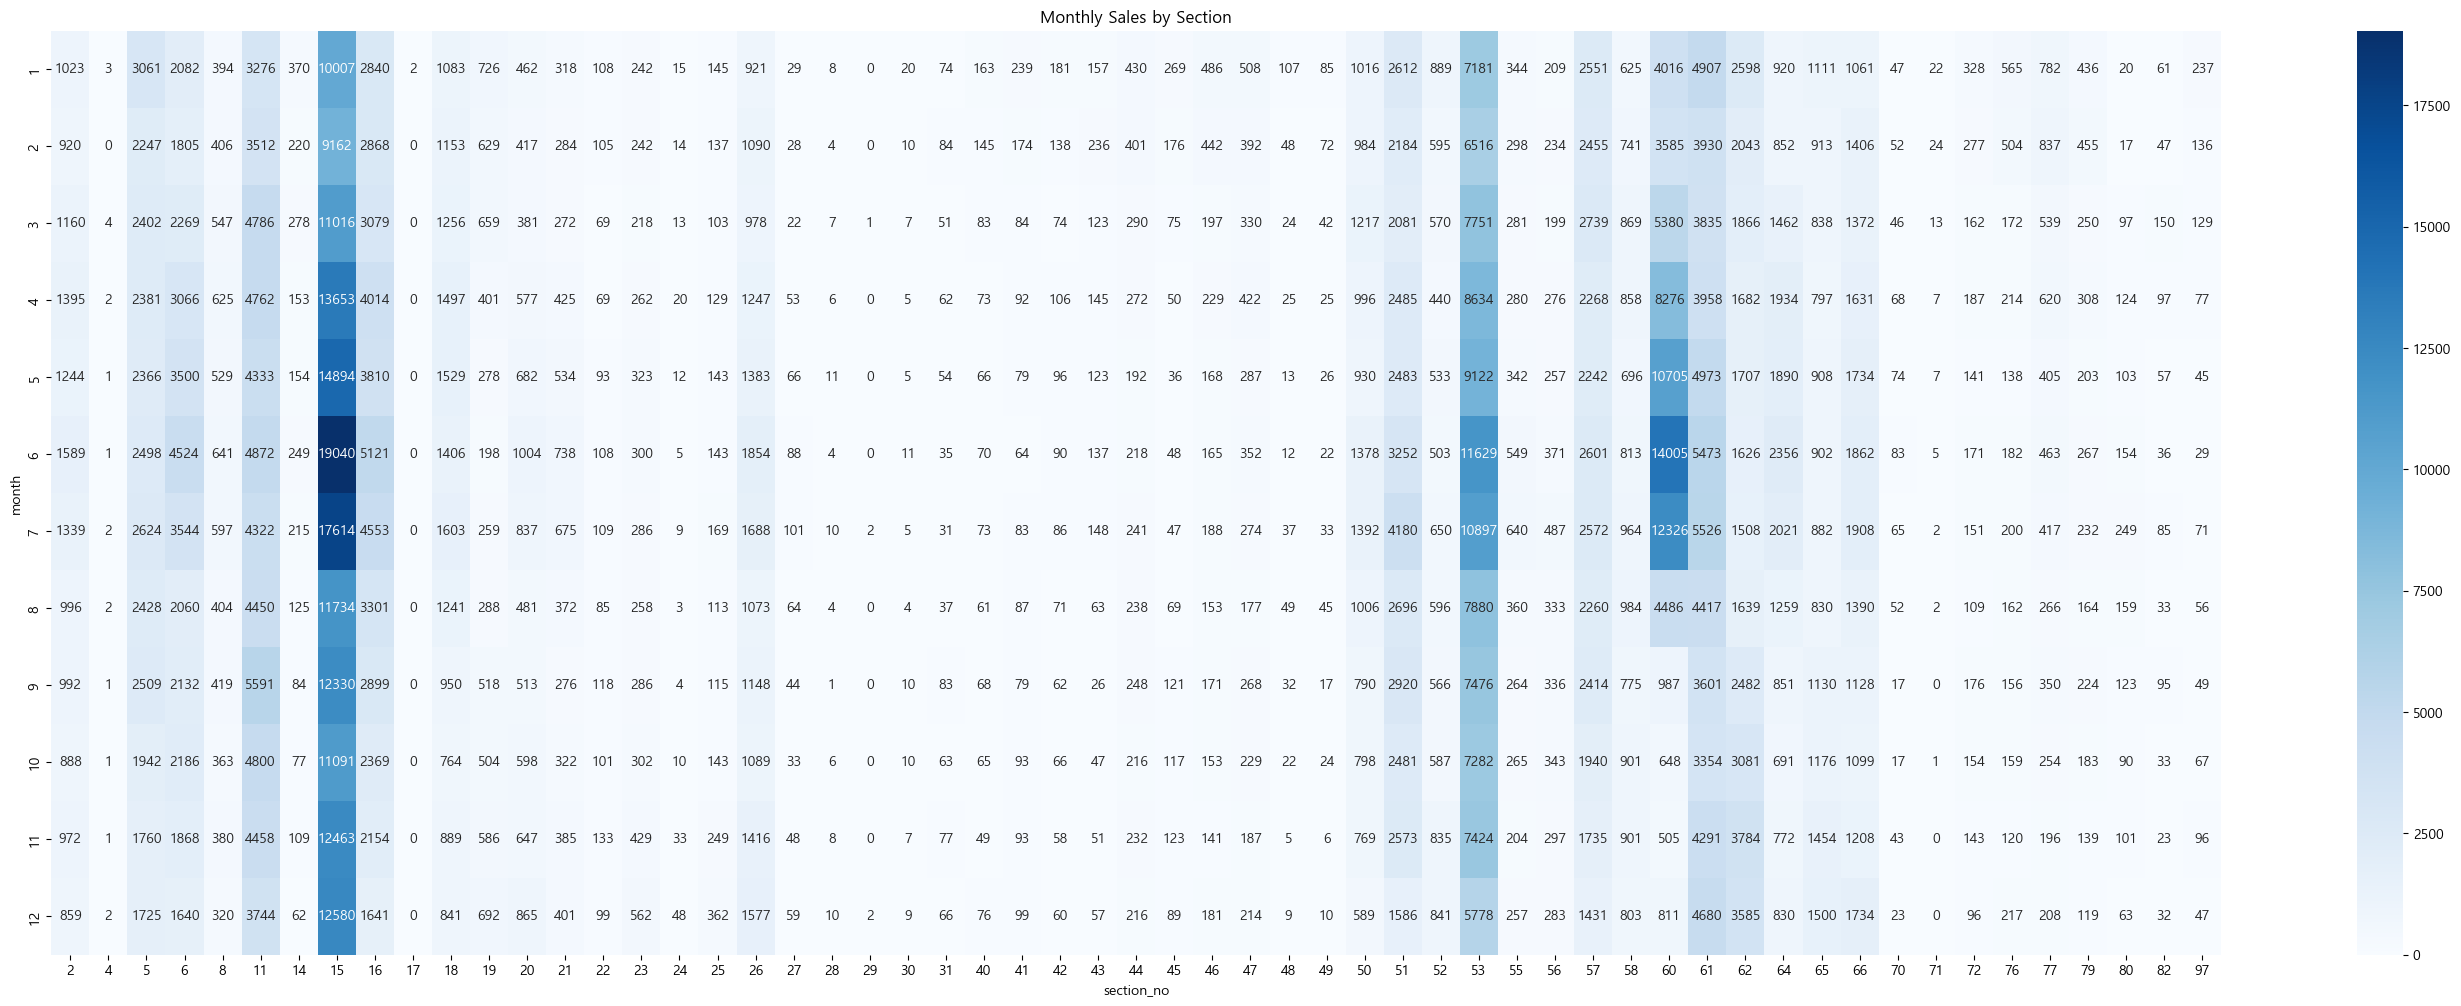

In [84]:
#그래프 사이즈
plt.figure(figsize=(35, 12)) 

#히트맵 그리기
sns.heatmap(pivot_data2, annot=True, cmap='Blues', fmt='d')

#타이틀
plt.title('Monthly Sales by Section')

#그래프 출력
plt.show()

- 15번 섹션 ⇒ Womens Everyday Collection
- 60번 섹션 ⇒ Womens Swimwear, beachwear
- 53번 섹션 ⇒ Divided Collection

____________________________________________________________________________________________

## 구매 횟수 별 ##

구매 횟수별

In [85]:
#구매횟수 구하기
hm_df2['purchase_count']=hm_df2.groupby('customer_id')['t_dat'].transform('nunique')
hm_df2['purchase_count']

0          6
1          2
2          1
3          1
4          2
          ..
803233     4
803234    30
803235     1
803236     7
803237     2
Name: purchase_count, Length: 801985, dtype: int64

_

In [86]:
# 고객 아이디 별 구매 횟수
purchase_count = hm_df2.groupby('customer_id')['article_id'].count()

In [87]:
# 고객 아이디 별 총 매출
customer_sales = hm_df2.groupby('customer_id')['price'].sum()

In [88]:
# 4분위 기준으로 나눠서 구매횟수 별 총 매출 집계

#개수 
bins = [0, 1, 2, 3, 60]
#범주 이름
labels = ['Q1', 'Q2', 'Q3', 'Q4']  

#범주화
purchase_count_quantile = pd.cut(purchase_count, bins=bins, labels=labels, right=True)
purchase_count_quantile.value_counts()


article_id
Q1    174367
Q2     77874
Q4     58671
Q3     39849
Name: count, dtype: int64

In [89]:
# 주문횟수별 총 매출 그룹화
sales_price = customer_sales.groupby(purchase_count_quantile).sum()

C:\Users\user\AppData\Local\Temp\ipykernel_1264\1885346638.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_price = customer_sales.groupby(purchase_count_quantile).sum()


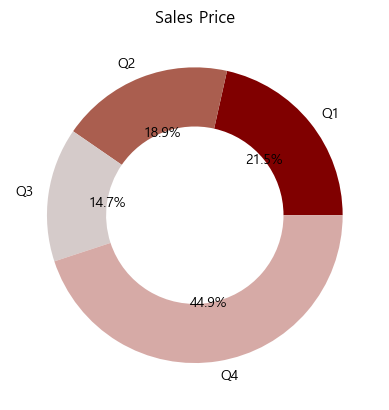

In [90]:
# 시각화
colors = ['#800000', '#AA5E4F','#D5CBCA' , '#D6AAA6']

#pie chart
plt.pie(sales_price, labels=sales_price.index, autopct='%.1f%%', wedgeprops=dict(width=0.4), colors=colors)
plt.title('Sales Price')
plt.show()

##################################################################################################

- 브랜드 충성도에 사용될 지표 정의
    - 제품 품질, 고객 서비스, 브랜드 평판, 가격전략, 정서적 연결
    - 고객 경험과 정서적 연결 중요

- 브랜드 충성도 지표를 정하고, 고객의 충성도를 계산하여 분류한다.
    - 브랜드 충성도를 선정하는 지표에 어떤 게 있는 지 탐색
    - 브랜드 충성도를 기준으로 고객 분류
    - 충성도 등급별 매출액 / 재구매율 / 많이 구매한 카테고리 탐색 / CLV
- 고객 생애 가치(CLV)
    
    고객이 비즈니스와 관계를 맺는 전체 기간동안 고객이 갖는 총 가치 
    
    기업은 신규 고객 확보 보다 기존 고객 유지 비용이 더 적기때문에 CLV의 가치를 높여야 함(고객과의 지속적인 긍정적 관계)

# 충성고객 분석 #

1. 브랜드 충성도 지표 설정
2. 브랜드 충성도 기준 고객 분류
3. CLV 지표 설정
4. 정합성 검증

____________________________________________________________________________

## 브랜드 충성도 지표 설정 ##

- 충성 고객
    - FN =1, ACTIVE = 1, STATUS = 'ACTIVE', 재구매  1회 이상
- 잠재 충성고객
    - FN =0, ACTIVE = 1, STATUS = 'ACTIVE','PRE-CREATE'
    - FN =1, ACTIVE = 0, STATUS = 'ACTIVE','PRE-CREATE'
    - FN =1, ACTIVE = 1, STATUS = 'PRE-CREATE'
    - FN =1, ACTIVE = 1, STATUS = 'ACTIVE', 재구매  0회
- 잠재 이탈고객
    - FN =0, ACTIVE = 0, STATUS = 'ACTIVE','PRE-CREATE'
- 탈퇴 고객
    - STATUS = 'LEFT CLUB'

In [91]:
# 충성고객 관련 컬럼 가져오고, customer_id 기준으로 중복값 제거
loyal_sc = hm_df2[['customer_id', 'FN', 'Active', 'club_member_status']].copy()
loyal_unique = loyal_sc.drop_duplicates(subset='customer_id', keep='first').sort_values('customer_id').reset_index(drop=True)

# 고객별 구매 기간 계산
purchase_span = hm_df2.groupby('customer_id')['t_dat'].agg(['min', 'max'])
purchase_span['days'] = (purchase_span['max'] - purchase_span['min']).dt.days + 1

# 두 테이블 병합
loyal_set = pd.merge(loyal_unique, purchase_span, how='inner', on='customer_id')


____________________________________________________________________________

## 브랜드 충성도 기준 고객분류 ##

In [92]:
# 충성도 등급 부여 함수
def loyal_grade(row):
    if row['club_member_status'] == 'LEFT CLUB':
        return 'lost'
    elif (row['FN'] == 1) and (row['Active'] == 1) and (row['club_member_status'] == 'ACTIVE') and (row['days'] <= 14):
        return 'loyal'
    elif (
        (((row['FN'] == 0) and (row['Active'] == 1)) or ((row['FN'] == 1) and (row['Active'] == 0))) and
        row['club_member_status'] in ['ACTIVE', 'PRE-CREATE'] and (row['days'] <= 14)
    ) or (
        (row['FN'] == 1) and (row['Active'] == 1) and
        ((row['club_member_status'] == 'PRE-CREATE') or ((row['club_member_status'] == 'ACTIVE') and (row['days'] == 1)))
    ) or (14 < row['days'] <= 30):
        return 'potential_loyal'
    elif (row['FN'] == 0) and (row['Active'] == 0) and (row['club_member_status'] in ['ACTIVE', 'PRE-CREATE']) or (row['days'] > 30):
        return 'at_risk'
    else:
        return 'ex'

# 충성도 등급 컬럼 추가
loyal_set['loyal_grade'] = loyal_set.apply(loyal_grade, axis=1)


In [93]:
# 고객 분류
loyal_cnt = loyal_set.groupby('loyal_grade')['customer_id'].count()
loyal_cnt

loyal_grade
at_risk            262613
lost                  110
loyal               77975
potential_loyal     10063
Name: customer_id, dtype: int64

In [94]:
# 고객 그룹 분리
loyal = loyal_set[(loyal_set['FN'] == 1) & (loyal_set['Active'] == 1) & (loyal_set['club_member_status'] == 'ACTIVE') & (loyal_set['days'] <= 14)]
potential_loyal = loyal_set[
    (
        (((loyal_set['FN'] == 0) & (loyal_set['Active'] == 1)) | ((loyal_set['FN'] == 1) & (loyal_set['Active'] == 0))) &
        loyal_set['club_member_status'].isin(['ACTIVE', 'PRE-CREATE']) & (loyal_set['days'] <= 14)
    ) |
    ((loyal_set['FN'] == 1) & (loyal_set['Active'] == 1) & ((loyal_set['club_member_status'] == 'PRE-CREATE') | ((loyal_set['club_member_status'] == 'ACTIVE') & (loyal_set['days'] == 1)))) |
    ((loyal_set['days'] > 14) & (loyal_set['days'] <= 30))
]
at_risk = loyal_set[(loyal_set['FN'] == 0) & (loyal_set['Active'] == 0) & (loyal_set['club_member_status'].isin(['ACTIVE', 'PRE-CREATE'])) | (loyal_set['days'] > 30)]
lost = loyal_set[loyal_set['club_member_status'] == 'LEFT CLUB']

# Step 1-1. 고객별 총 구매 금액 및 구매 횟수 구하기
total_price = hm_df2.groupby('customer_id').agg(
    total_spent=('price', 'sum'),
    purchase_count=('customer_id', 'count')  # 🔹 추가된 부분
).reset_index()

# 데이터 병합
merged_full = pd.merge(loyal_set, total_price, on='customer_id', how='left')

# 평균 구매 금액 계산 (구매 횟수가 0인 경우 대비)
merged_full['avg_purchase_value'] = merged_full['total_spent'] / merged_full['purchase_count'].replace(0, 1)

# Step 4. loyal_grade별 평균 구매 금액과 연간 방문 수 계산
summary = merged_full.groupby('loyal_grade').agg(
    avg_purchase_value=('avg_purchase_value', 'mean'),
    avg_annual_visits=('purchase_count', 'mean')
).reset_index()

# Step 5. CLV 계산 (수명 연수 = 1년)
summary['CLV'] = summary['avg_purchase_value'] * summary['avg_annual_visits']

print(summary)

       loyal_grade  avg_purchase_value  avg_annual_visits    CLV
0          at_risk              22,940                  3 59,902
1             lost              25,236                  2 58,502
2            loyal              22,170                  1 26,702
3  potential_loyal              22,588                  2 49,550


CLV 계산

고객 등급별 많이 구매한 카테고리

In [95]:
# Step 1. 거래 데이터(hm_df2)에 고객 등급 붙이기
hm_df2_loyal = pd.merge(hm_df2, loyal_set[['customer_id', 'loyal_grade']], on='customer_id', how='left')

# Step 2. 거래 데이터에 상품 정보 붙이기 (product_group_name 얻기 위해)
# full_df = pd.merge(hm_df2_loyal, articles_hm[['article_id', 'product_group_name']], on='article_id', how='left')

# Step 3. 등급별 × 상품그룹별 구매 건수 집계
result = hm_df2_loyal.groupby(['loyal_grade', 'product_group_name']).size().reset_index(name='purchase_count')

# Step 3. 피벗 테이블로 보기 좋게 변환
pivot_result = result.pivot(index='product_group_name', columns='loyal_grade', values='purchase_count').fillna(0)

# Step 4. 결과 출력
print(pivot_result)

loyal_grade            at_risk  lost  loyal  potential_loyal
product_group_name                                          
Accessories             34,342    12  4,917            1,163
Bags                       147     1     16                8
Cosmetic                    20     0      1                3
Furniture                   24     0      2                0
Garment Full body       77,223    19  9,801            2,502
Garment Lower body     153,760    63 20,463            4,975
Garment Upper body     269,157   108 37,610            8,219
Garment and Shoe care        4     0      0                0
Items                       73     0      8                4
Nightwear                7,547     6    979              230
Shoes                   16,483     7  2,023              504
Socks & Tights          13,711     1  2,184              482
Swimwear                58,844    14  8,464            2,276
Underwear               53,410    24  7,322            1,669
Underwear/nightwear     

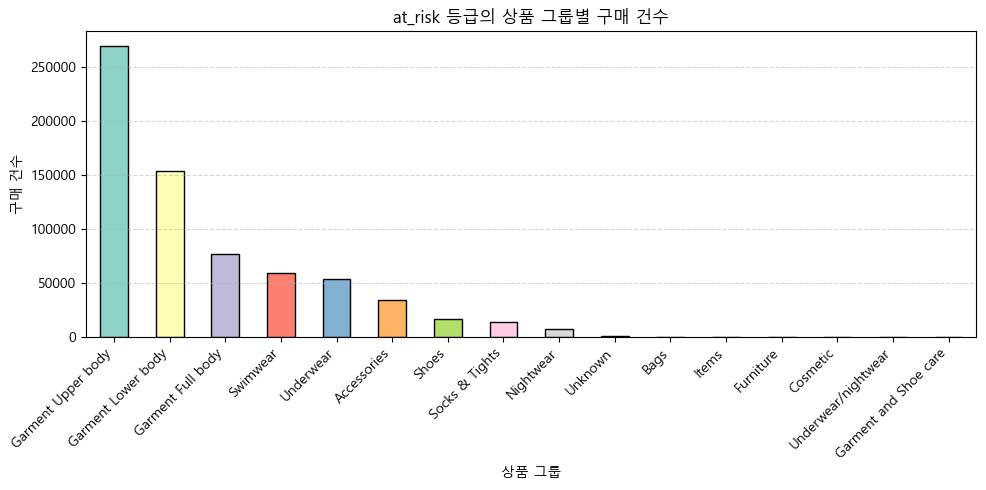

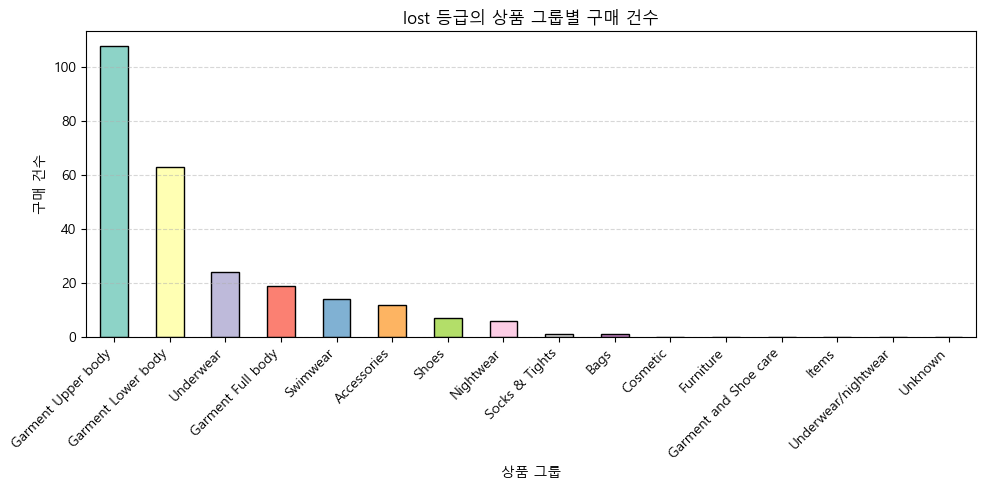

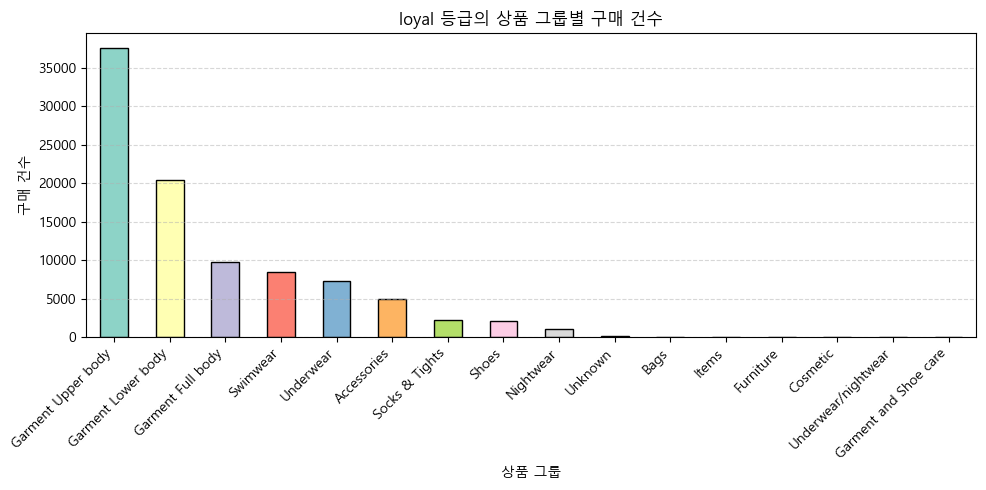

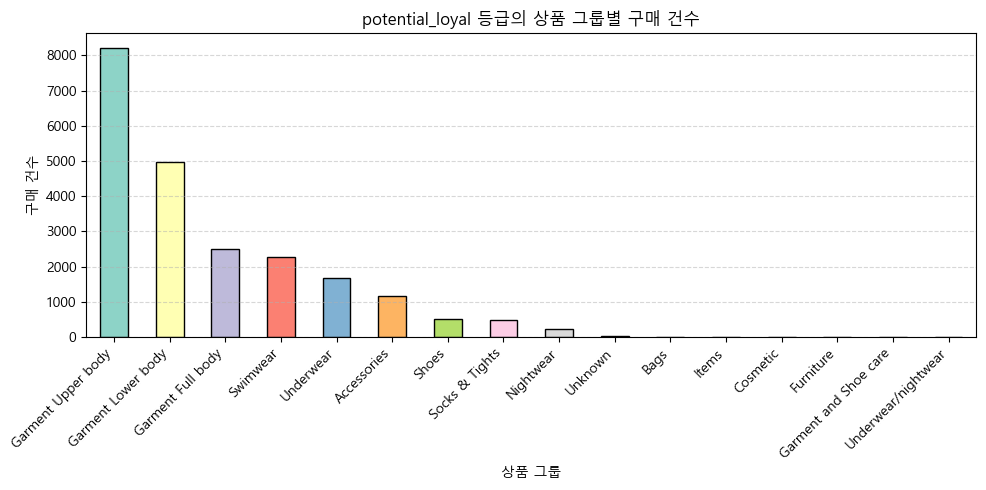

In [96]:
for grade in pivot_result.columns:
    plt.figure(figsize=(10, 5))
    pivot_result[grade].sort_values(ascending=False).plot(
        kind='bar',
        color=plt.cm.Set3.colors,  # 컬러 팔레트 자동 적용
        edgecolor='black'
    )
    plt.title(f'{grade} 등급의 상품 그룹별 구매 건수')
    plt.xlabel('상품 그룹')
    plt.ylabel('구매 건수')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


### 🔍 패턴 분석

1. **충성 고객 평균 CLV: 82139.44**
    - 가장 가치 있는 고객군으로, 1인당 평균 82139.44을 지출
    - 기업에 대한 충성도가 높아 지속적인 구매를 하는 고객
2. **잠재 충성 고객 평균 CLV: 79819.47**
    - 충성 고객이 될 가능성이 있는 고객군
    - 현재 평균 79819.47을 지출하고 있으며, 적절한 마케팅 전략을 통해 충성 고객으로 전환가능
3. **잠재 이탈 고객 평균 CLV: 49220.05**
    - 이탈 가능성이 높은 고객군으로, 평균 49220.05을 지출
    - 유지 전략이 필요하며, 맞춤 혜택이나 리텐션 캠페인이 효과적
4. **탈퇴 고객 평균 CLV: 58501.53**
    - 이미 이탈한 고객이지만 과거 평균 58501.53을 지출했던 고객군
    - 재활성화 전략을 통해 일부 고객을 다시 유치할 가능성 존재

**주요 시사점**

- 충성 고객이 가장 높은 CLV를 보이며, 이들을 유지하는 것이 가장 중요.
- 잠재 충성 고객을 효과적으로 관리하면 충성 고객으로 전환 가능성 존재.
- 잠재 이탈 고객은 특별 관리가 필요하며, 조기 대응 전략이 중요.
- 탈퇴 고객이 잠재 이탈 고객보다 높은 CLV를 기록한 점을 보면, 이탈 고객 일부는 가치 있는 고객일 가능성이 있어 재유치를 시도할 필요 존재.

즉, **충성 고객 유지와 잠재 충성 고객 전환이 핵심 전략**이며, **잠재 이탈 고객과 탈퇴 고객을 대상으로 한 맞춤형 리텐션 전략도 고려**

### 마케팅 전략 제안

1. 충성 고객: 프리미엄 서비스 강화 (예: VIP 프로그램)
    - 크로스셀링 기회 활용
2. 잠재 이탈 고객: 리텐션 캠페인 강화 (예: 타겟팅 쿠폰)
    - 이탈 위험 지표 모니터링 시스템 구축
3. 탈퇴 고객: 재유치 프로그램 개발 (예: 웰컴백 오퍼)
    - 이탈 원인 분석 설문 조사 실시

전체 고객 재구매율

In [97]:
#전체 재구매율
# t_dat 날짜 타입으로 변경 
hm_df2['t_dat'] = pd.to_datetime(hm_df2['t_dat'])

#날짜 오름차순 정렬
trans_cus_df = hm_df2.sort_values(by=['customer_id', 't_dat'])

# 고객별로 구매일 사이의 간격 구하기
trans_cus_df['diff_days'] = trans_cus_df.groupby('customer_id')['t_dat'].diff().dt.days

customer_cycle = trans_cus_df.groupby('customer_id')['diff_days'].mean().reset_index()

customer_cycle

#diff_days가 NaN → 한 번만 구매한 고객
#diff_days가 0 이상인 값 → 2번 이상 구매한 고객
#→ 평균 간격이 0일인 경우는 같은 날 2번 이상 산 경우

,customer_id,diff_days
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,126
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,19
2,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,NaN
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,42
4,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,53
...,...,...
350756,c88f00357e7b1518128c80043e5d2b223308a3ce3fc389...,NaN
350757,c88f0d813c429ceb32683c9cb5fcb24331ff198e6e17f2...,NaN
350758,c88f5971612e659a4e90d6f08d9c29bdf1e4268fcf52d5...,0
350759,c88f99a55b10f6dd50dd87c3ca05af4a8a6c98f3e6fbc5...,0


In [98]:
# 전체 고객 수
total_customers = hm_df2['customer_id'].nunique()

# 재구매 고객 수 (NaN이 아닌 값 & 0 초과인 경우만 포함)
repeat_customers = customer_cycle[customer_cycle['diff_days'] > 0]['customer_id'].nunique()

# 재구매율 계산
repeat_purchase_rate = repeat_customers / total_customers * 100

print(f'재구매 고객 수: {repeat_customers}')
print(f'전체 고객 수: {total_customers}')
print(f'재구매율: {repeat_purchase_rate:.2f}%')

재구매 고객 수: 149929
전체 고객 수: 350761
재구매율: 42.74%


____________________________________________________________________________

## CLV 지표 설정 ##

고객 생애가치

기본 계산 방법
CLV = 고객 가치 × 평균 고객 수명

여기서:

고객 가치 = 평균 구매 가치 × 평균 구매 빈도

평균 구매 가치 = 특정 기간 내 총 수익 ÷ 특정 기간 내 총 구매 횟수

평균 구매 빈도 = 특정 기간 내 구매 횟수 ÷ 특정 기간 내 총 고객 수

평균 고객 수명 = 고객이 지속적으로 구매한 기간 ÷ 총 고객 수

In [99]:
# 1. 고객별 총 구매 금액
customer_total_price = hm_df2.groupby('customer_id')['price'].sum()

# 2. 고객별 구매 횟수
customer_purchase_count = hm_df2.groupby('customer_id')['price'].count()

# 3. 고객별 평균 구매 금액
customer_avg_price = customer_total_price / customer_purchase_count

# 4. 구매 주기 계산용 날짜 처리(평균 고객 수명)
purchase_span = hm_df2.groupby('customer_id')['t_dat'].agg(['min', 'max'])
purchase_span['days'] = (purchase_span['max'] - purchase_span['min']).dt.days + 1

# 5. 고객별 간단 CLV 계산 (여기선 평균 구매금액 * 구매 횟수)
#clv_df = pd.DataFrame({'customer_id': customer_avg_price.index, 'CLV': customer_avg_price * customer_purchase_count})
clv_df = pd.DataFrame({'CLV': customer_avg_price * customer_purchase_count}).sort_index()

clv_df 

,CLV
customer_id,
00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657,"90,863"
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,"172,900"
0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d8cd0c725276a467a2a,"21,975"
00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,"89,719"
00009d946eec3ea54add5ba56d5210ea898def4b46c68570cf0096d962cacc75,"122,250"
...,...
c88f00357e7b1518128c80043e5d2b223308a3ce3fc3893a732de1f232b8034d,"51,295"
c88f0d813c429ceb32683c9cb5fcb24331ff198e6e17f259440f4b220ab8212a,"14,645"
c88f5971612e659a4e90d6f08d9c29bdf1e4268fcf52d56ff8c53e2c24157209,"35,448"


#### RFM 통계지표

**Recency(최근성)**:

- 최근 구매일이 낮을수록(=최근에 구매했을수록) 점수가 높아야 함
- 따라서, **Min-Max 스케일링 후 `1 - recency`를 적용**하여 값을 반전
- (즉, 최근 구매 고객일수록 높은 값, 오래된 고객일수록 낮은 값)

**Frequency(빈도) & Monetary(구매금액)**

- Min-Max 스케일링을 적용하여 0~1 사이로 변환
- 값이 클수록 높은 점수를 받게 됨

**세 가지 요소(Recency, Frequency, Monetary)를 합산하여 점수(score) 계산**

- 최근에 구매했을수록
- 자주 구매했을수록
- 많은 금액을 지출했을수록

**⇒ 높은 점수를 받음**

In [100]:
hm_df2['month'] = hm_df2['t_dat']
hm_df2

,t_dat,customer_id,article_id,price,sales_channel_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,...,Active,club_member_status,fashion_news_frequency,age,Z-score,z-score_age,month,weekend,age_group,purchase_count
0,2019-11-05,3e2b60b679e62fb49516105b975560082922011dd752ec...,698328010,"14,645",2,698328,ZEBRA CF TVP,252,Sweater,Garment Upper body,...,1,ACTIVE,Regularly,51,-1,1,2019-11-05,Weekday,50대,6
1,2019-05-22,89647ac2274f54c770aaa4b326e0eea09610c252381f37...,760597002,"29,305",2,760597,BUBBLE WRAP TOP,254,Top,Garment Upper body,...,0,ACTIVE,NONE,28,0,-1,2019-05-22,Weekday,20대,2
2,2019-05-10,2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...,488561032,"14,645",2,488561,Teddy jogger.,274,Shorts,Garment Lower body,...,1,ACTIVE,Regularly,37,-1,0,2019-05-10,Weekday,30대,1
3,2019-08-26,7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...,682771001,"29,305",2,682771,Yuki shopper,66,Bag,Accessories,...,0,ACTIVE,NONE,19,0,-1,2019-08-26,Weekday,10대,1
4,2019-08-10,3b77905de8b32045f08cedb79200cdfa477e9562429a39...,742400033,"2,785",1,742400,1pk Sportsock,302,Socks,Socks & Tights,...,0,ACTIVE,NONE,35,-1,-0,2019-08-10,Weekend,30대,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
803233,2019-03-25,8e900818a1da0e73300a012794615993fbefb43f851430...,766346001,"21,975",2,766346,Kanta RW Slacks,273,Leggings/Tights,Garment Lower body,...,0,ACTIVE,NONE,21,-0,-1,2019-03-25,Weekday,20대,4
803234,2019-10-18,13aa106eeb8a6fa2f9e2ab888a3a2ee118a3900670f0d8...,811905001,"14,645",2,811905,J Sunray,265,Dress,Garment Full body,...,1,ACTIVE,Regularly,39,-1,0,2019-10-18,Weekday,30대,30
803235,2019-04-06,5f51e21397c1248aafdf9712435bd4be063eb093f56229...,690108001,"18,794",2,690108,Straight 5pkt Lowprice,272,Trousers,Garment Lower body,...,1,ACTIVE,Regularly,44,-0,1,2019-04-06,Weekend,40대,1
803236,2019-03-20,3421bd479ee13287a65660cf816b01d0d803d1d6d0fe73...,583534002,"14,645",2,583534,Bradley,272,Trousers,Garment Lower body,...,0,ACTIVE,NONE,51,-1,1,2019-03-20,Weekday,50대,7


In [101]:
#1. Recency(최근성): 분석 기준 날짜에서 마지막 구매 날짜까지의 기간
#2. Frequency(빈도): 특정 기간 동안이 구매 횟수
#3. Monetary(금액): 특정 기간 동안의 총 구매 금액

# 날짜 데이터 변환
df = hm_df2.copy()
df['date'] = pd.to_datetime(df['t_dat'])
df['year_month'] = df['date'].dt.to_period('M')  # 'YYYY-MM' 형태로 변환

# 월별 Recency 계산
last_day_per_month = df.groupby('year_month')['date'].max().reset_index()
last_day_per_month.rename(columns={'date': 'month_end_date'}, inplace=True)

recency_df = df.groupby(['customer_id', 'year_month'])['date'].max().reset_index()
recency_df = recency_df.merge(last_day_per_month, on='year_month')
recency_df['recency'] = (recency_df['month_end_date'] - recency_df['date']).dt.days
recency_df = recency_df[['customer_id', 'year_month', 'recency']]

# 월별 Frequency 계산
frequency_df = df.groupby(['customer_id', 'year_month']).agg({'article_id': 'nunique'}).rename(columns={'article_id': 'frequency'}).reset_index()

# 월별 Monetary 계산
monetary_df = df.groupby(['customer_id', 'year_month']).agg({'price': 'sum'}).rename(columns={'price': 'monetary'}).reset_index()

# RFM 데이터프레임 병합
rfm_df = recency_df.merge(frequency_df, on=['customer_id', 'year_month']).merge(monetary_df, on=['customer_id', 'year_month'])

# 결과 확인
print(rfm_df.head())
print(rfm_df.describe())


                                         customer_id year_month  recency  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...    2019-05        6   
1  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...    2019-09        2   
2  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...    2019-05        9   
3  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...    2019-06       12   
4  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...    2019-07       26   

   frequency  monetary  
0          1    43,965  
1          1    46,897  
2          2    65,941  
3          1    21,975  
4          2    65,941  
       recency  frequency  monetary
count  610,959    610,959   610,959
mean        14          1    30,208
std          9          1    22,988
min          0          1       220
25%          6          1    14,645
50%         13          1    23,456
75%         22          1    38,072
max         30         16   457,157


In [102]:
#Min max scale = 최대값을 1, 최소값을 0으로 표준화하는 기법
from sklearn.preprocessing import minmax_scale

#최근성은 숫자가 작을수록, 즉 최근 구매일이 얼마 지나지 않은 고객이 더 점수가 높음
#최근성이 높은 고객이 더 높은 점수를 받도록 하기 위해서 스케일링 후, recency 값을 1에서 빼면 값을 반전
#값이 작아서 스케일링 후 0에 가까운 값은 1에 가깝게 되고, 스케일링 후 1에 가까운 값은 0에 가까워짐
# Min-Max Scaling
rfm_df['recency'] = minmax_scale(rfm_df['recency'], axis=0, copy=True)
rfm_df['recency'] = 1 - rfm_df['recency']  # 최근성이 높은 고객이 높은 점수를 받도록 변환
rfm_df['frequency'] = minmax_scale(rfm_df['frequency'], axis=0, copy=True)
rfm_df['monetary'] = minmax_scale(rfm_df['monetary'], axis=0, copy=True)

# RFM 점수 계산
rfm_df['score'] = rfm_df['recency'] + rfm_df['frequency'] + rfm_df['monetary']
rfm_df['score'] = minmax_scale(rfm_df['score'], axis=0, copy=True) * 100
rfm_df['score'] = round(rfm_df['score'], 0)

# 등급 부여
rfm_df['grade'] = rfm_df['score'].apply(lambda x: 'A' if x >= 40 else ('B' if x >= 30 else ('C' if x >= 20 else ('D' if x >= 10 else 'F'))))



grade
C    178305
B    151436
D    149659
F    117692
A     13867
Name: count, dtype: int64


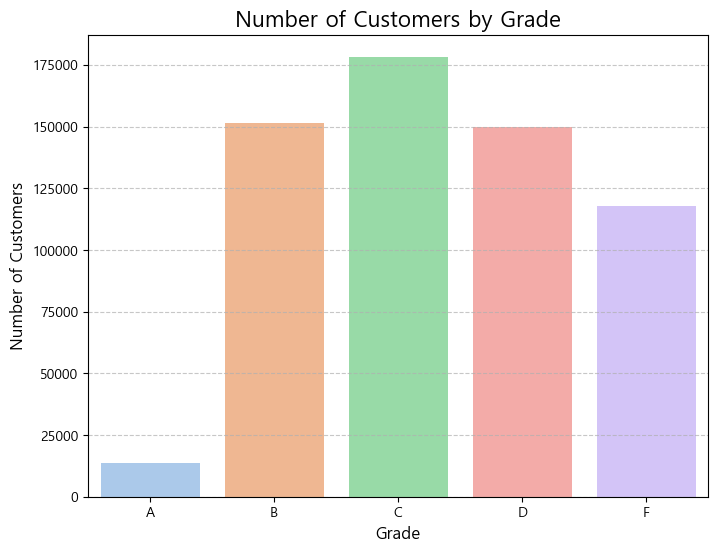

In [103]:
#등급별 고객 수 계산
grade_counts = rfm_df['grade'].value_counts()
print(grade_counts)

#'A', 'B', 'C', 'D', 'F' 순으로 정렬
grade_order = ['A', 'B', 'C', 'D', 'F']
grade_counts = grade_counts[grade_order]

#막대 차트 생성
plt.figure(figsize=(8, 6))
sns.barplot(x=grade_counts.index, y=grade_counts.values, hue=grade_counts.index, palette='pastel')
plt.title('Number of Customers by Grade', fontsize=16)
plt.xlabel('Grade', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Figure size 1200x600 with 0 Axes>

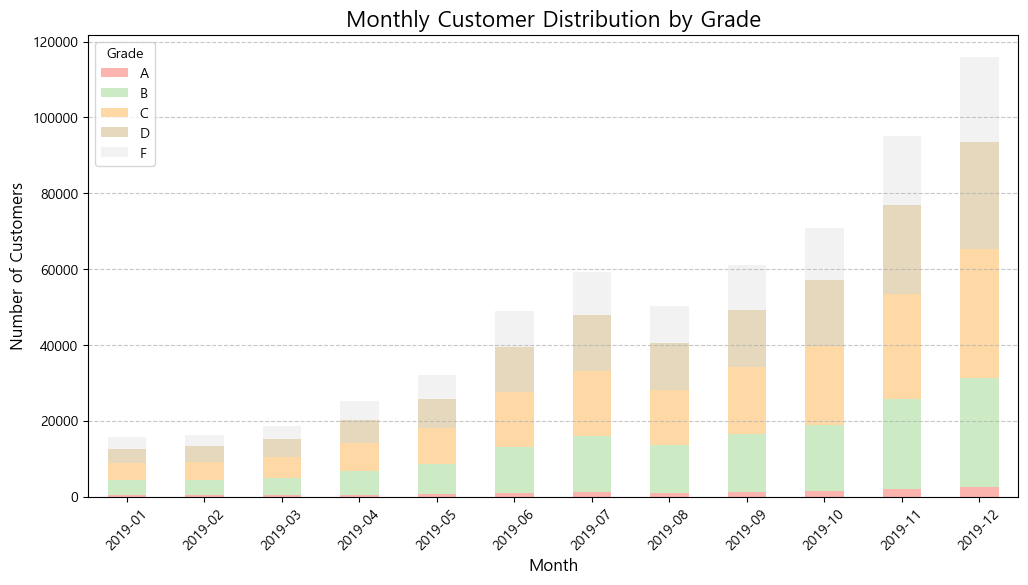

In [104]:
# 최신 거래 기준 month 컬럼 추가
rfm_df['month'] = df.groupby('customer_id')['year_month'].transform('max')

# 월별 등급별 고객 수 계산
monthly_grade_counts = rfm_df.groupby(['month', 'grade']).size().unstack(fill_value=0)

# 시각화: 월별 등급별 고객 분포 변화
plt.figure(figsize=(12, 6))
monthly_grade_counts.plot(kind='bar', stacked=True, cmap='Pastel1', figsize=(12, 6))

plt.title('Monthly Customer Distribution by Grade', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Grade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

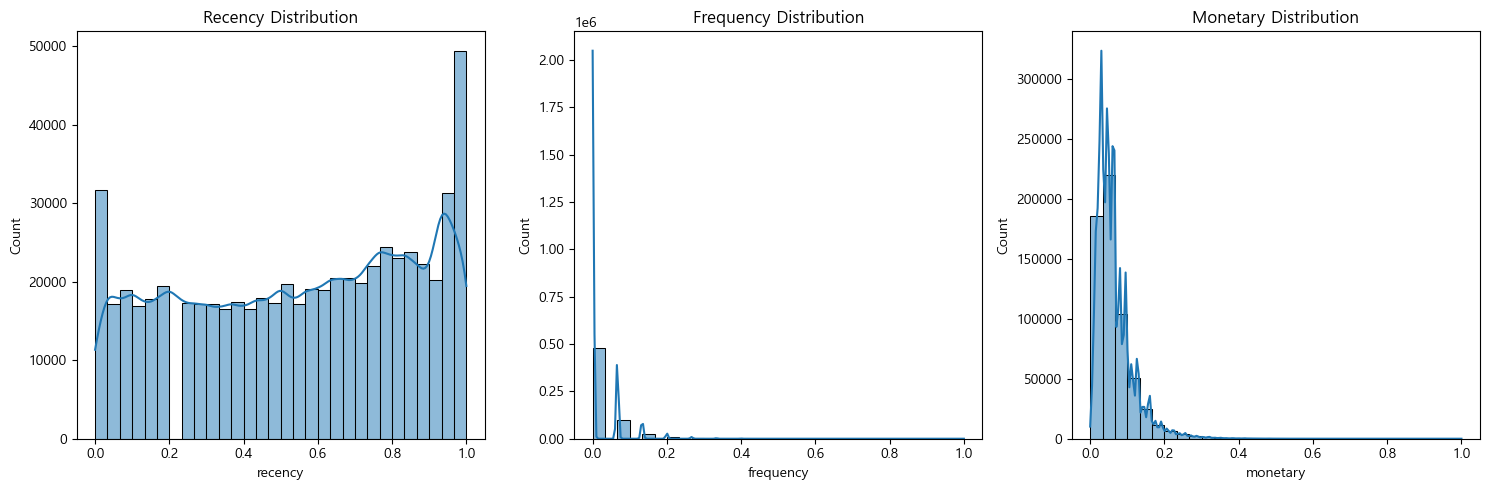

In [105]:
# Recency, Frequency, Monetary 분포 확인
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(rfm_df['recency'], bins=30, kde=True)
plt.title('Recency Distribution')

plt.subplot(1, 3, 2)
sns.histplot(rfm_df['frequency'], bins=30, kde=True)
plt.title('Frequency Distribution')

plt.subplot(1, 3, 3)
sns.histplot(rfm_df['monetary'], bins=30, kde=True)
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

In [106]:
rfm_avg_by_grade1 = (
    rfm_df.groupby('grade')[['recency', 'frequency', 'monetary']]
    .mean()
)

# 소수점 둘째 자리까지 출력되도록 설정
print(rfm_avg_by_grade1.applymap(lambda x: f"{x:.2f}"))


      recency frequency monetary
grade                           
A        0.93      0.16     0.20
B        0.89      0.03     0.07
C        0.65      0.02     0.06
D        0.36      0.01     0.06
F        0.11      0.01     0.05


C:\Users\user\AppData\Local\Temp\ipykernel_1264\2750974236.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(rfm_avg_by_grade1.applymap(lambda x: f"{x:.2f}"))


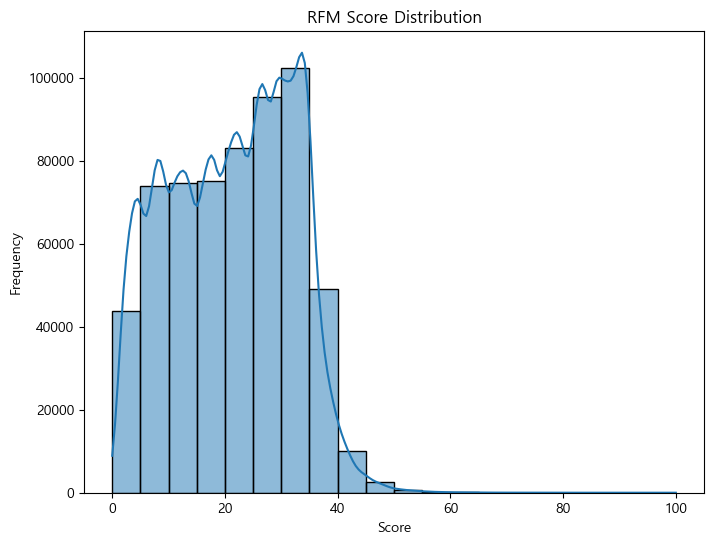

In [107]:
# RFM 점수 분포 확인
plt.figure(figsize=(8, 6))
sns.histplot(rfm_df['score'], bins=20, kde=True)
plt.title('RFM Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

In [108]:
from scipy.stats import f_oneway

# 각 등급별 Recency, Frequency, Monetary에 대한 ANOVA 검정
for feature in ['recency', 'frequency', 'monetary']:
    groups = [rfm_df[rfm_df['grade'] == grade][feature] for grade in ['A', 'B', 'C', 'D', 'F']]
    f_stat, p_value = f_oneway(*groups)
    print(f'{feature} ANOVA test: F-statistic={f_stat:.2f}, p-value={p_value:.5f}')

recency ANOVA test: F-statistic=1275584.16, p-value=0.00000
frequency ANOVA test: F-statistic=51534.37, p-value=0.00000
monetary ANOVA test: F-statistic=39123.56, p-value=0.00000


### CLV 정합성

In [109]:
# 충성도 분류 함수
def loyal_grade(row):
    if row['club_member_status'] == 'LEFT CLUB':
        return 'lost'
    elif (row['FN'] == 1) and\
    (row['Active'] == 1) and\
    (row['club_member_status'] == 'ACTIVE') and\
    (row['days'] <= 14 ):
        return 'loyal'
    elif(
        (
            ((row['FN'] == 0) and (row['Active'] == 1)) or\
            ((row['FN'] == 1) and (row['Active'] == 0))
        ) and\
        row['club_member_status'] in (['ACTIVE', 'PRE-CREATE']) and\
        (row['days'] <= 14)  # 최근 2주 이내 구매자
    ) or\
    (
        (row['FN'] == 1) and\
        (row['Active'] == 1) and\
        (
            (row['club_member_status'] == 'PRE-CREATE') or\
            (
                (row['club_member_status'] == 'ACTIVE') and\
                (row['days'] == 1)
            ) 
        )
    ) or (14 < row['days'] <= 30):
        return 'potential_loyal'
    elif (row['FN'] == 0) and\
    (row['Active'] == 0) and\
    (row['club_member_status'] in (['ACTIVE', 'PRE-CREATE'])) or\
    (row['days'] > 30):
        return 'at_risk'
    else:
        return 'ex'

# 고객 정보와 마지막 구매일 계산
hm_df2['t_dat'] = pd.to_datetime(hm_df2['t_dat'])
max_date = hm_df2['t_dat'].max()
last_purchase = hm_df2.groupby('customer_id')['t_dat'].max().reset_index()
last_purchase['days'] = (max_date - last_purchase['t_dat']).dt.days
purchase_counts = hm_df2.groupby('customer_id').size().reset_index(name='purchase_count')
customer_info = hm_df2.drop_duplicates(subset='customer_id')[['customer_id', 'FN', 'Active', 'club_member_status']]

# 고객 테이블 결합
loyal_set = customer_info.merge(last_purchase, on='customer_id', how='left')
loyal_set = loyal_set.merge(purchase_counts, on='customer_id', how='left')

# 구매 횟수가 1회 이상인 고객만
loyal_set = loyal_set[loyal_set['purchase_count'] >= 1]

# 충성도 그룹 분류
loyal_set['loyal_grade'] = loyal_set.apply(loyal_grade, axis=1)

# 그룹별 고객 수 확인
loyal_cnt = loyal_set.groupby('loyal_grade')['customer_id'].count()
print("충성도 그룹별 고객 수:\n", loyal_cnt)

# CLV 계산
clv = hm_df2.groupby('customer_id')['price'].sum().reset_index(name='CLV')
loyal_set = loyal_set.merge(clv, on='customer_id', how='left')

# 각 그룹 별 고객 수 출력
loyal = loyal_set[loyal_set['loyal_grade'] == 'loyal']
potential_loyal = loyal_set[loyal_set['loyal_grade'] == 'potential_loyal']
at_risk = loyal_set[loyal_set['loyal_grade'] == 'at_risk']
lost = loyal_set[loyal_set['loyal_grade'] == 'lost']

# 결과 출력
print("충성 고객 수:", len(loyal))
print("잠재 충성 고객 수:", len(potential_loyal))
print("잠재 이탈 고객 수:", len(at_risk))
print("탈퇴 고객 수:", len(lost))

충성도 그룹별 고객 수:
 loyal_grade
at_risk            318721
lost                  110
loyal               11516
potential_loyal     20414
Name: customer_id, dtype: int64
충성 고객 수: 11516
잠재 충성 고객 수: 20414
잠재 이탈 고객 수: 318721
탈퇴 고객 수: 110


In [110]:
# 각 그룹의 평균 CLV 출력
print("충성 고객 평균 CLV:", loyal['CLV'].mean())
print("잠재 충성 고객 평균 CLV:", potential_loyal['CLV'].mean())
print("잠재 이탈 고객 평균 CLV:", at_risk['CLV'].mean())
print("탈퇴 고객 평균 CLV:", lost['CLV'].mean())

# CLV가 예상대로 증가하는지 비교
clv_values = {
    '충성 고객': loyal['CLV'].mean(),
    '잠재 충성 고객': potential_loyal['CLV'].mean(),
    '잠재 이탈 고객': at_risk['CLV'].mean(),
    '탈퇴 고객': lost['CLV'].mean()
}

# 정합성 검증
for grade in ['충성 고객', '잠재 충성 고객', '잠재 이탈 고객', '탈퇴 고객']:
    print(f'{grade} 평균 CLV: {clv_values[grade]}')

# 정합성 조건 확인
if (clv_values['충성 고객'] > clv_values['잠재 충성 고객'] > clv_values['잠재 이탈 고객']):
    print("CLV의 정합성: 예상대로 CLV 값이 증가합니다.")
else:
    print("CLV의 정합성 오류: CLV 값 순서가 예상과 다릅니다.")

충성 고객 평균 CLV: 84360.57649771341
잠재 충성 고객 평균 CLV: 79041.9945487319
잠재 이탈 고객 평균 CLV: 49774.7434522254
탈퇴 고객 평균 CLV: 57659.24588138727
충성 고객 평균 CLV: 84360.57649771341
잠재 충성 고객 평균 CLV: 79041.9945487319
잠재 이탈 고객 평균 CLV: 49774.7434522254
탈퇴 고객 평균 CLV: 57659.24588138727
CLV의 정합성: 예상대로 CLV 값이 증가합니다.


In [111]:
# Step 1-1. 고객별 총 구매 금액 구하기
total_price = hm_df2.groupby('customer_id')['price'].sum().reset_index(name='total_spent')

# 합치기
merged_full = pd.merge(loyal_set, total_price, on='customer_id', how='left')

# 평균 구매 금액 계산
merged_full['avg_purchase_value'] = merged_full['total_spent'] / merged_full['purchase_count']

# Step 4. loyal_grade별 평균 구매 금액과 연간 방문 수
summary = merged_full.groupby('loyal_grade').agg(
    avg_purchase_value=('avg_purchase_value', 'mean'),
    avg_annual_visits=('purchase_count', 'mean')
).reset_index()

# Step 5. CLV 계산 (수명 연수 = 1년)
summary['CLV'] = summary['avg_purchase_value'] * summary['avg_annual_visits']

print(summary)

       loyal_grade  avg_purchase_value  avg_annual_visits    CLV
0          at_risk              22,690                  2 49,220
1             lost              25,236                  2 58,502
2            loyal              21,588                  4 82,139
3  potential_loyal              24,491                  3 79,819


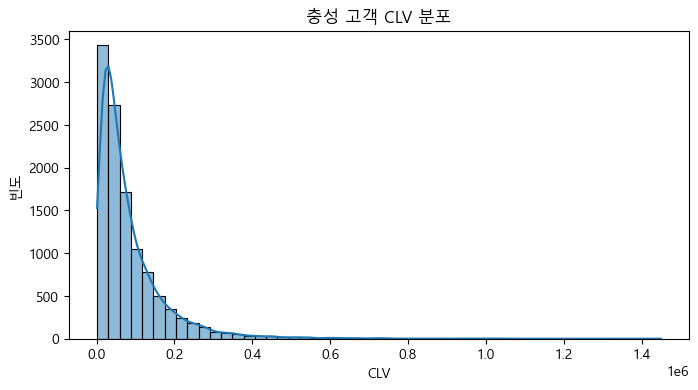

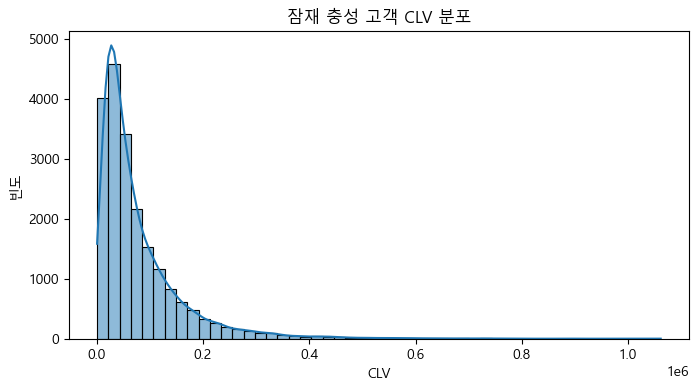

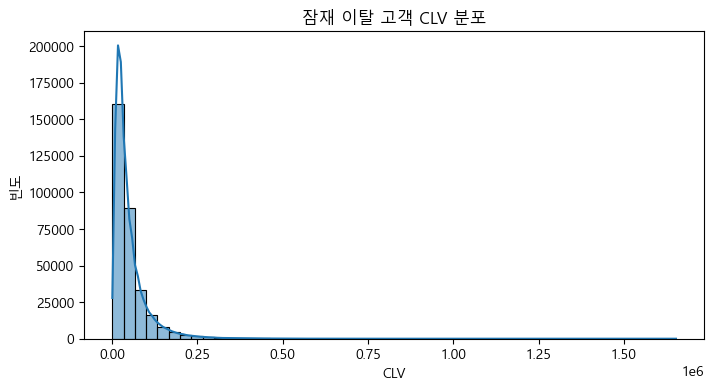

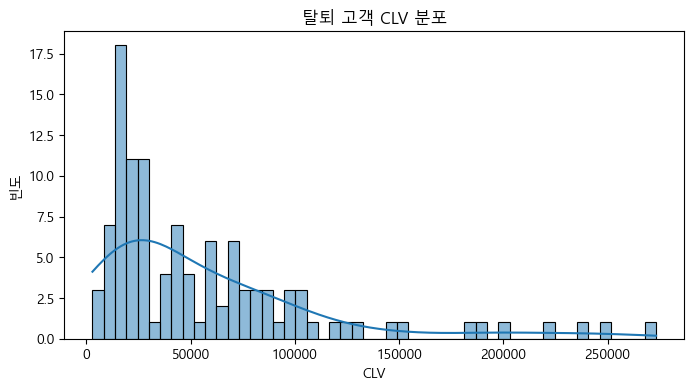

In [112]:
#제시된 CLV 값들 간의 관계가 논리적으로 맞는지 확인
#일반적으로는 충성고객 > 잠재 충성 고개 > 잠재 이탈 고객 > 탈퇴 고객
#하지만 우리 데이터는 탈퇴고객이 잠재 이탈보다 높음
#이탈 고객이 왜 더 많이 지출했는가 파악

def plot_clv_distribution(clv, label):
    plt.figure(figsize=(8, 4))
    sns.histplot(clv['CLV'], bins=50, kde=True)
    plt.title(f'{label} CLV 분포')
    plt.xlabel('CLV')
    plt.ylabel('빈도')
    plt.show()

# 고객군별 CLV 분포 시각화
plot_clv_distribution(loyal, "충성 고객")
plot_clv_distribution(potential_loyal, "잠재 충성 고객")
plot_clv_distribution(at_risk, "잠재 이탈 고객")
plot_clv_distribution(lost, "탈퇴 고객")

In [113]:
#이상치 분석
def check_outliers(df, label):
    q1 = df['CLV'].quantile(0.25)
    q3 = df['CLV'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[(df['CLV'] < lower_bound) | (df['CLV'] > upper_bound)]
   
    print(f"{label} 이상치 고객 수: {len(outliers)} / {len(df)}")
    print(f"{label} CLV 범위: min={df['CLV'].min()}, max={df['CLV'].max()}, Q1={q1}, Q3={q3}")
    print("-" * 50)

# 각 고객군의 CLV 이상치 확인
check_outliers(loyal, "충성 고객")
check_outliers(potential_loyal, "잠재 충성 고객")
check_outliers(at_risk, "잠재 이탈 고객")
check_outliers(lost, "탈퇴 고객")

충성 고객 이상치 고객 수: 753 / 11516
충성 고객 CLV 범위: min=1304.7403665000002, max=1449214.29690674, Q1=26373.3396335, Q3=107274.550450795
--------------------------------------------------
잠재 충성 고객 이상치 고객 수: 1364 / 20414
잠재 충성 고객 CLV 범위: min=864.9399999999999, max=1061340.01774236, Q1=28532.024882720005, Q3=101249.29040315
--------------------------------------------------
잠재 이탈 고객 이상치 고객 수: 24398 / 318721
잠재 이탈 고객 CLV 범위: min=293.19995602, max=1652929.6571413002, Q1=19043.33986806, Q3=60062.02002932
--------------------------------------------------
탈퇴 고객 이상치 고객 수: 7 / 110
탈퇴 고객 CLV 범위: min=2917.33969214, max=273291.71853400004, Q1=19226.58994869, Q3=73402.61975811
--------------------------------------------------


In [114]:
from scipy import stats

# 그룹별 CLV 리스트
clv_values = [
    loyal['CLV'].dropna(),
    potential_loyal['CLV'].dropna(),
    at_risk['CLV'].dropna(),
    lost['CLV'].dropna()
]

# ANOVA 검정 수행
f_stat, p_value = stats.f_oneway(*clv_values)
print(f"ANOVA 검정 결과: F-statistic={f_stat:.2f}, p-value={p_value:.5f}")

# 유의미한 차이가 있는지 확인
if p_value < 0.05:
    print("고객군 간 CLV 평균 차이가 통계적으로 유의함!")
else:
    print("고객군 간 CLV 평균 차이가 유의하지 않음 (데이터 검토 필요).")

ANOVA 검정 결과: F-statistic=2930.34, p-value=0.00000
고객군 간 CLV 평균 차이가 통계적으로 유의함!


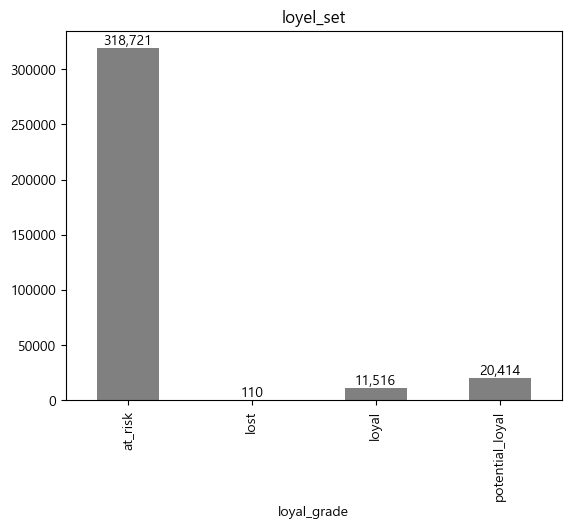

In [115]:
#충성 그룹별 고객 수 확인 
loyal_cnt = loyal_set.groupby('loyal_grade')['customer_id'].count()
loyal_cnt.plot.bar(color='grey')

# 그래프 제목 설정
plt.title("loyel_set")

# 바 위에 숫자 표시
bars = plt.gca().patches  # 현재 그래프의 바 객체 가져오기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # 바의 x 위치 중앙
        height + 500,                      # 바 위로 약간의 여백 추가
        f'{height:,.0f}',                  # 숫자 형식 지정
        ha='center', va='bottom', fontsize=10  # 가운데 정렬 및 폰트 크기 설정
    )

plt.show()

충성고객 재분류 2

- CLV 계산 최최최종
    - CLV 공식
    
    예) 공식: CLV = USD 5(평균 매출) x 100(연간 방문) x 5(년) = USD 2500

In [116]:
# 고객별 총 구매 금액 (CLV)
clv = hm_df2.groupby('customer_id')['price'].sum().reset_index(name='total_spent')

# 인당 평균 금액 = 총 지출액 / 고객 수
def print_avg_spent(df, label):
    merged = df.merge(clv, on='customer_id', how='left')
    avg = merged['total_spent'].mean()
    print(f"{label} 평균 CLV (고객 1인당 평균 지출): {round(avg, 2)}")

# 각 그룹별 평균 CLV 출력
print_avg_spent(loyal, "충성 고객")
print_avg_spent(potential_loyal, "잠재 충성 고객")
print_avg_spent(at_risk, "잠재 이탈 고객")
print_avg_spent(lost, "탈퇴 고객")

충성 고객 평균 CLV (고객 1인당 평균 지출): 84360.58
잠재 충성 고객 평균 CLV (고객 1인당 평균 지출): 79041.99
잠재 이탈 고객 평균 CLV (고객 1인당 평균 지출): 49774.74
탈퇴 고객 평균 CLV (고객 1인당 평균 지출): 57659.25


C:\Users\user\AppData\Local\Temp\ipykernel_1264\1875849362.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='고객 분류', y='평균 CLV', data=df, palette='Reds_r')


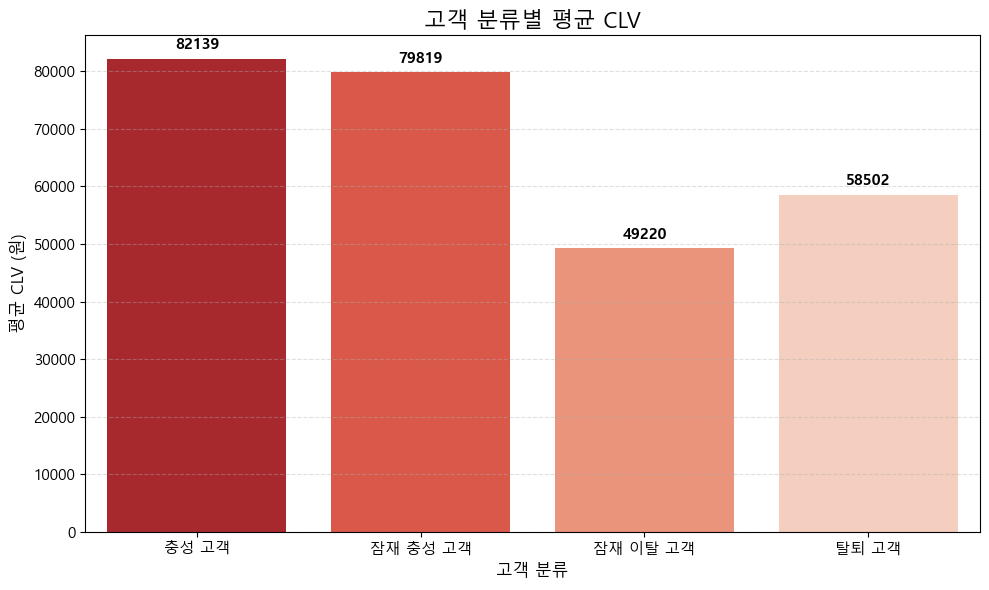

In [117]:
import matplotlib.pyplot as plt
import numpy as np
plt.rc('font', family='Malgun Gothic')  # Windows 사용자는 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

data = {
    '고객 분류': ['충성 고객', '잠재 충성 고객', '잠재 이탈 고객', '탈퇴 고객'],
    '평균 CLV': [82139.44, 79819.48, 49220.05, 58501.53]
}
df = pd.DataFrame(data)


# 시각화
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='고객 분류', y='평균 CLV', data=df, palette='Reds_r')

# 막대 위에 숫자 표시
for i, row in df.iterrows():
    barplot.text(i, row['평균 CLV'] + 1000, f"{row['평균 CLV']:.0f}", 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# 디테일 조정
plt.title('고객 분류별 평균 CLV', fontsize=16)
plt.ylabel('평균 CLV (원)', fontsize=12)
plt.xlabel('고객 분류', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


## 등급별 많이 구매한 카테고리 ##

충성고객

잠재 이탈고객

이탈고객

전체 고객 재구매율

## 정합성 검증 ## 

In [118]:
hm_df2.head().T

,0,1,2,3,4
t_dat,2019-11-05 00:00:00,2019-05-22 00:00:00,2019-05-10 00:00:00,2019-08-26 00:00:00,2019-08-10 00:00:00
customer_id,3e2b60b679e62fb49516105b975560082922011dd752ec...,89647ac2274f54c770aaa4b326e0eea09610c252381f37...,2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...,7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...,3b77905de8b32045f08cedb79200cdfa477e9562429a39...
article_id,698328010,760597002,488561032,682771001,742400033
price,"14,645","29,305","14,645","29,305","2,785"
sales_channel_id,2,2,2,2,1
product_code,698328,760597,488561,682771,742400
prod_name,ZEBRA CF TVP,BUBBLE WRAP TOP,Teddy jogger.,Yuki shopper,1pk Sportsock
product_type_no,252,254,274,66,302
product_type_name,Sweater,Top,Shorts,Bag,Socks
product_group_name,Garment Upper body,Garment Upper body,Garment Lower body,Accessories,Socks & Tights


In [119]:
hm_df2.columns

Index(['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id',
       'product_code', 'prod_name', 'product_type_no', 'product_type_name',
       'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc', 'FN', 'Active',
       'club_member_status', 'fashion_news_frequency', 'age', 'Z-score',
       'z-score_age', 'month', 'weekend', 'age_group', 'purchase_count'],
      dtype='object')

In [120]:
# Point-Biserial Correlation
# 연속형 변수와 이분형 범주형 변수에 대한 상관관계 구하기 
r, p_value = stats.pointbiserialr(hm_df2['sales_channel_id'], hm_df2['price'])
r, p_value

# r = 0.17 로 상관관계가 높지 않음
# p-value 가 0.05 보다 작으므로, 이는 통계적으로 신뢰를 가지고 판단할 수 있음 

(np.float64(0.17757755679290677), np.float64(0.0))

In [121]:
# ANOVA
# 연속형 변수의 평균이 범주형 변수에 따라 차이가 있는지 분석하는 방법
# 범주형 변수별 그룹 분할
# 카테고리를 club_member_status 의 unique 값들로 지정하고, 이를 모든 행에 적용(for문), 결과적으로 필터링 된 데이터셋 중에서
# price 컬럼만 가져오는 코드 
groups = [hm_df2['price'][hm_df2['club_member_status'] == category] for category in hm_df2['club_member_status'].unique()]

# ANOVA 검정 수행
# F <1 : 무의미
# 1 <= F < 3 : 거의 무의미 
# 3 <= F <10 : 경우에 따라 유의미
# 10 <= F < 50 : 유의미(강한차이)
# F > 50 : 거의 확실한 유의미(아주 강한차이)
# F >= 100 : 확실한 유의미(매우 강한차이)
# F 값이 큰것만 확인하는 것이 아니라, 이를 통계적으로 설명 가능한 지 P-value 도 함께 봐야 합니다. (즉, 0.05 미만인지 봐야합니다.)
# 이 말은 곧, F 값이 크게 나왔지만, P-value 가 0.05 보다 크다면, 통계적으로 설명할 수 없다는 것을 의미합니다. 
# 클럽 멤버상태와 결제 금액은 매우 강한 상관관계가 있습니다. 

anova_result = stats.f_oneway(*groups)
print(f"ANOVA 검정 결과: F={anova_result.statistic:.4f}, p-value={anova_result.pvalue:.4f}")

ANOVA 검정 결과: F=205.1164, p-value=0.0000


# RFM분석 #

### RFM 분석의 절차

1. 데이터 수집: 고객의 구매 이력 데이터를 수집.
2. RFM 값 계산: 각 고객에 대해 Recency, Frequency, Monetary 값을 계산
3. RFM 점수 부여: 각 요소에 대해 점수를 부여. 예를 들어, Recency는 최근 구매일이 가까울수록 높은 점수를, Frequency와 Monetary는 값이 클수록 높은 점수를 부여.
4. 고객 세분화: RFM 점수를 조합하여 고객을 여러 그룹으로 분류. 예를 들어, 높은 점수를 받은 고객은 '잠재적 충성 고객'으로, 낮은 점수를 받은 고객은 '잠재적 이탈 고객'으로 분류
5. 마케팅 전략 수립: 각 고객 그룹에 적합한 마케팅 전략을 수립. 예를 들어, 잠재 충성 고객에게는 충성 고객으로 끌어 올릴 수 있는 구매 혜택을 제공하고, 잠재적 이탈 고객에게는 재구매를 유도하는 프로모션을 진행.

**Recency(최근성)**:

- 최근 구매일이 낮을수록(=최근에 구매했을수록) 점수가 높아야 함
- 따라서, **Min-Max 스케일링 후 `1 - recency`를 적용**하여 값을 반전
- (즉, 최근 구매 고객일수록 높은 값, 오래된 고객일수록 낮은 값)

**Frequency(빈도) & Monetary(구매금액)**

- Min-Max 스케일링을 적용하여 0~1 사이로 변환
- 값이 클수록 높은 점수를 받게 됨

**세 가지 요소(Recency, Frequency, Monetary)를 합산하여 점수(score) 계산**

- 최근에 구매했을수록
- 자주 구매했을수록
- 많은 금액을 지출했을수록

**⇒ 높은 점수를 받음**

In [122]:
#1. Recency(최근성): 분석 기준 날짜에서 마지막 구매 날짜까지의 기간
#2. Frequency(빈도): 특정 기간 동안이 구매 횟수
#3. Monetary(금액): 특정 기간 동안의 총 구매 금액

#날짜 데이터 변환
df = hm_df2.copy()
df['date'] = pd.to_datetime(df['t_dat'])
df['year_month'] = df['date'].dt.to_period('M')  # 'YYYY-MM' 형태로 변환

#월별 Recency 계산
last_day_per_month = df.groupby('year_month')['date'].max().reset_index()
last_day_per_month.rename(columns={'date': 'month_end_date'}, inplace=True)

recency_df = df.groupby(['customer_id', 'year_month'])['date'].max().reset_index()
recency_df = recency_df.merge(last_day_per_month, on='year_month')
recency_df['recency'] = (recency_df['month_end_date'] - recency_df['date']).dt.days
recency_df = recency_df[['customer_id', 'year_month', 'recency']]

#월별 Frequency 계산
frequency_df = df.groupby(['customer_id', 'year_month']).agg({'article_id': 'nunique'}).rename(columns={'article_id': 'frequency'}).reset_index()

#월별 Monetary 계산
monetary_df = df.groupby(['customer_id', 'year_month']).agg({'price': 'sum'}).rename(columns={'price': 'monetary'}).reset_index()

#RFM 데이터프레임 병합
rfm_df = recency_df.merge(frequency_df, on=['customer_id', 'year_month']).merge(monetary_df, on=['customer_id', 'year_month'])

#결과 확인
print(rfm_df.head())
print(rfm_df.describe())


                                         customer_id year_month  recency  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...    2019-05        6   
1  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...    2019-09        2   
2  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...    2019-05        9   
3  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...    2019-06       12   
4  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...    2019-07       26   

   frequency  monetary  
0          1    43,965  
1          1    46,897  
2          2    65,941  
3          1    21,975  
4          2    65,941  
       recency  frequency  monetary
count  610,959    610,959   610,959
mean        14          1    30,208
std          9          1    22,988
min          0          1       220
25%          6          1    14,645
50%         13          1    23,456
75%         22          1    38,072
max         30         16   457,157


In [123]:
#Min max scale = 최대값을 1, 최소값을 0으로 표준화하는 기법
from sklearn.preprocessing import minmax_scale

#최근성은 숫자가 작을수록, 즉 최근 구매일이 얼마 지나지 않은 고객이 더 점수가 높음
#최근성이 높은 고객이 더 높은 점수를 받도록 하기 위해서 스케일링 후, recency 값을 1에서 빼면 값을 반전
#값이 작아서 스케일링 후 0에 가까운 값은 1에 가깝게 되고, 스케일링 후 1에 가까운 값은 0에 가까워짐
#Min-Max Scaling
rfm_df['recency'] = minmax_scale(rfm_df['recency'], axis=0, copy=True)
rfm_df['recency'] = 1 - rfm_df['recency']  # 최근성이 높은 고객이 높은 점수를 받도록 변환
rfm_df['frequency'] = minmax_scale(rfm_df['frequency'], axis=0, copy=True)
rfm_df['monetary'] = minmax_scale(rfm_df['monetary'], axis=0, copy=True)

#RFM 점수 계산
rfm_df['score'] = rfm_df['recency'] + rfm_df['frequency'] + rfm_df['monetary']
rfm_df['score'] = minmax_scale(rfm_df['score'], axis=0, copy=True) * 100
rfm_df['score'] = round(rfm_df['score'], 0)

#등급 부여
rfm_df['grade'] = rfm_df['score'].apply(lambda x: 'A' if x >= 40 else ('B' if x >= 30 else ('C' if x >= 20 else ('D' if x >= 10 else 'F'))))



grade
C    178305
B    151436
D    149659
F    117692
A     13867
Name: count, dtype: int64


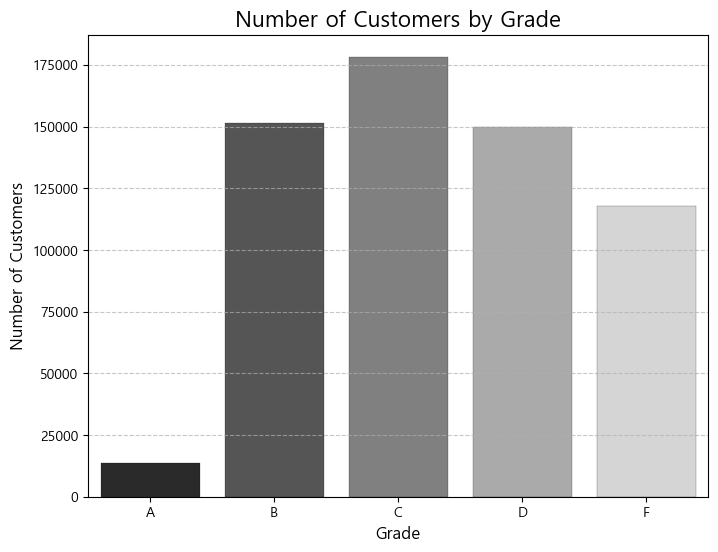

In [124]:
#등급별 고객 수 계산
grade_counts = rfm_df['grade'].value_counts()
print(grade_counts)

#'A', 'B', 'C', 'D', 'F' 순으로 정렬
grade_order = ['A', 'B', 'C', 'D', 'F']
grade_counts = grade_counts[grade_order]

#막대 차트 생성
plt.figure(figsize=(8, 6))
sns.barplot(x=grade_counts.index, y=grade_counts.values, hue=grade_counts.index, palette='gray',linewidth=0.15, edgecolor='black')
plt.title('Number of Customers by Grade', fontsize=16)
plt.xlabel('Grade', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **[등급별 고객 분포 & 해석]**

- **A (13,867명, 약 2.7%)**
    
    → **최우수 고객** 
    
    → **Recency(최근성)**: 최근에 구매한 고객
    
    → **Frequency(구매 빈도)**: 자주 구매하는 고객
    
    → **Monetary(구매 금액)**: 높은 소비를 하는 고객
    
    → **해석**: 충성도가 높고, 지속적인 마케팅(멤버십 혜택, 맞춤형 추천 등)으로 유지할 가치가 있는 고객군
    
- **B (151,436명, 약 29.5%)**
    
    → **우수 고객** 
    
    → **Recency(최근성)**: 최근에 구매한 고객이 많음
    
    → **Frequency(구매 빈도)**: 비교적 높은 편
    
    → **Monetary(구매 금액)**: 중간~높음
    
    → **해석**: A등급보다 한 단계 낮지만, 적절한 프로모션을 제공하면 A등급으로 성장 가능
    
- **C (178,305명, 약 34.7%)**
    
    → **일반 고객** 
    
    → **Recency(최근성)**: 최근 구매 고객과 과거 구매 고객이 섞여 있음
    
    → **Frequency(구매 빈도)**: 중간 정도
    
    → **Monetary(구매 금액)**: 중간 수준
    
    →  **해석**: 이탈 가능성이 있어 리마인드 마케팅(이메일, 쿠폰 등)을 활용할 필요가 있음
    
- **D (149,659명, 약 29.1%)**
    
    → **저활성 고객** 
    
    → **Recency(최근성)**: 마지막 구매가 오래됨
    
    → **Frequency(구매 빈도)**: 낮음
    
    → **Monetary(구매 금액)**: 낮음
    
    →  **해석**: 거의 이탈한 고객, 재참여 유도를 위해 할인 쿠폰 제공, 개인화 메시지 등 필요
    
- **F (117,692명, 약 22.9%)**
    
    → **이탈 고객** 
    
    → **Recency(최근성)**: 오랜 기간 구매 없음
    
    → **Frequency(구매 빈도)**: 매우 낮음
    
    → **Monetary(구매 금액)**: 매우 낮음
    
    → **해석**: 이 고객들은 거의 브랜드를 떠났다고 볼 수 있음. 재활성화 캠페인(이전 구매 기반 맞춤 추천, 강력한 프로모션) 등을 시도해볼 필요 있음.

구매 패턴 분석(월별)